In [2]:
import sys
import subprocess
import shutil
from importlib import metadata


def install_gnn_dependencies():
    # Detect Python version
    version = f"{sys.version_info.major}.{sys.version_info.minor}"
    print(f"Detected Python {version}")

    # Map Python versions to compatible Torch versions
    if version == "3.12":
        torch_ver = "2.2.0"
    else:
        torch_ver = "2.1.0"

    has_nvidia_smi = shutil.which("nvidia-smi") is not None
    use_cuda = has_nvidia_smi

    if use_cuda:
        cuda_tag = "cu121"
        desired_torch = f"{torch_ver}+{cuda_tag}"
        torch_index = f"https://download.pytorch.org/whl/{cuda_tag}"
        pyg_index = f"https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html"
        print(f"GPU detected. Target Torch build: {desired_torch}")
    else:
        desired_torch = torch_ver
        torch_index = "https://download.pytorch.org/whl/cpu"
        pyg_index = f"https://data.pyg.org/whl/torch-{torch_ver}+cpu.html"
        print(f"No GPU detected. Target Torch build: {desired_torch}")

    print("Executing installation...")

    try:
        installed_torch = metadata.version("torch")
        print(f"Existing torch installation detected: {installed_torch}")
    except metadata.PackageNotFoundError:
        installed_torch = None
        print("Torch is not currently installed.")

    try:
        # Step 1: Install Torch only when needed
        if installed_torch == desired_torch:
            print("Step 1: Torch already matches the target build. Skipping reinstall.")
        else:
            print("Step 1: Installing Torch...")
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", "--user", "--upgrade", "--no-cache-dir",
                f"torch=={torch_ver}", "--index-url", torch_index
            ])

        # Step 2: Ensure NumPy compatibility
        print("Step 2: Installing NumPy 1.26.4...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--user", "--upgrade", "--no-cache-dir",
            "numpy==1.26.4"
        ])

        # Step 3: Install PyG extensions matching Torch/CUDA build
        print("Step 3: Installing GNN extensions (pyg-lib/scatter/sparse)...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--user", "--upgrade", "--no-cache-dir",
            "pyg-lib", "torch-scatter", "torch-sparse", "-f", pyg_index
        ])

        # Step 4: Install remaining project requirements
        print("Step 4: Installing remaining requirements...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--user", "--upgrade", "--no-cache-dir",
            "-r", "requirements.txt"
        ])

        print("\n✓ Environment configured.")
        print("IMPORTANT: Restart the notebook kernel after install so Torch reloads correctly.")

    except subprocess.CalledProcessError as e:
        print(f"\n× Installation failed at command: {e.cmd}")
        print(f"Error code: {e.returncode}")
        print("If disk quota fails again, switch to the CPU build or free more space in ~/.local/lib/python3.10/site-packages.")
        print("Ensure internet access, disk space, and compatible NVIDIA driver/CUDA runtime.")


install_gnn_dependencies()

Detected Python 3.10
GPU detected. Target Torch build: 2.1.0+cu121
Executing installation...
Existing torch installation detected: 2.1.0+cu121
Step 1: Torch already matches the target build. Skipping reinstall.
Step 2: Installing NumPy 1.26.4...



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Step 3: Installing GNN extensions (pyg-lib/scatter/sparse)...
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Step 4: Installing remaining requirements...
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
Ignoring torch: markers 'python_version >= "3.12"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 187.6 MB/s  0:00:00
Ignoring torch-scatter: markers 'python_version >= "3.12"' don't match your environment
Ignoring torch-sparse: markers 'python_version >= "3.12"' don't match your environment
  Attempting uninstall: torch-scatter
    Found existing installation: torch-scatter 2.1.2+pt21cu121
    Uninstalling torch-scatter-2.1.2+pt21cu121:
      Successfully uninstalled torch-scatter-2.1.2+pt21cu121
  Attempting uninstall: torch-sparse━━━━━━━━━━━━ 0/2 [torch-scatter]
    Found existing installation: torch-sparse 0.6.18+pt21cu121[torch-scatter]
    Uninstalling torch-sparse-0.6.18+pt21cu121:m 0/2 [torch-scatter]
      Successfully uninstalled torch-sparse-0.6.18+pt21cu121m [torch-scatter]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Download the scotiabank data files

In [3]:
import gdown
import zipfile
import os
from csv_to_gzip import csv_to_gzip

data_path = "data"
# Check for required files in data directory
files_to_check = [
    "data/labels.csv.gz",
    "data/kyc_individual.csv.gz",
    "data/kyc_smallbusiness.csv.gz",
    "data/card.csv.gz"
]

files_exist = all(os.path.exists(f) for f in files_to_check)
files_exist = files_exist and os.path.isdir(data_path) and len(os.listdir(data_path)) == 12

if files_exist:
    print("Required files found. Skipping download.")
else:
    print("Required files missing. Downloading dataset...")
    
    # Download data.zip
    url = "https://drive.google.com/file/d/1A7w3GqZTCVsv-A8gXj5NKV2FNc0zoduG/view?usp=sharing"
    zip_path = "data.zip"

    print("Downloading data.zip...")
    gdown.download(url, zip_path, fuzzy=True)
    print("Download complete.")

    # Extract the zip file
    print("Extracting data.zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data")
    print("Extraction complete.")

    # Compress all CSV files in the data directory to .csv.gz
    print("Compressing CSV files to gzip...")
    for filename in os.listdir(data_path):
        if filename.endswith('.csv'):
            csv_path = os.path.join(data_path, filename)
            csv_to_gzip(csv_path)
            print(f"Compressed {filename} to {filename}.gz")
            os.remove(csv_path)

    # Clean up the zip file
    os.remove(zip_path)
    print("Cleaned up data.zip")

print("Data files ready in 'data' directory")


Required files found. Skipping download.
Data files ready in 'data' directory


# Feature Engineering

Build the master transaction pool by combining BankSim and Scotiabank data sources and computing temporal behavioral features. These features are used across the autoencoder, GraphSAGE, and DGI pipeline stages.

# GraphSAGE — Inductive Fraud Detection

### Design Choices for Inductive Learning

Rather than passing edge features into the convolution (GAT-style), we **pre-aggregate transaction features into the customer node** itself. This means any new customer node can be fully described using only their own KYC data + a few transaction aggregates — no need to re-embed the whole graph.

**Customer node (12 features):**
- KYC: `age, income, tenure, sales, entity_type`
- Transaction aggregates: `avg_txn_amount, max_txn_amount, std_txn_amount, txn_count, cash_rate, ecom_rate, avg_24h_velocity`

**Category / City nodes:** learned embeddings (initialized to one-hot, updated during training)

**Graph edges:** customer -> category, customer -> city (bidirectional via `ToUndirected`)

**Leakage controls in this notebook:**
- `velocity_24h` is prior-only (`closed='left'`)
- customer train/val/test split is temporal (by customer first-seen transaction time)
- customer aggregate features are built with split-aware cutoffs (point-in-time safe)

# Prepare transaction nodes for GraphSAGE

Combine the BankSim and Scotiabank transactions into a unified master pool aligned to the card schema:

**Schema**
[transaction_id, customer_id, amount_cad, debit_credit, transaction_datetime, merchant_category, ecommerce_ind, cash_indicator, country, province, city, is_fraud, source_dataset, time_delta, velocity_24h, cust_idx, cat_idx, city_idx]

**Field definitions**
- **transaction_id**: Unique transaction identifier (BankSim uses `BS_{i}`).
- **customer_id**: Unique customer identifier.
- **amount_cad**: Transaction amount in CAD (BankSim amounts multiplied by 1.62 from EUR).
- **debit_credit**: Debit/credit flag (BankSim uses `debit`; Scotiabank uses source values).
- **transaction_datetime**: Transaction timestamp (BankSim derived from `step`).
- **merchant_category**: Mapped industry category or transfer type.
- **ecommerce_ind**: 1 if e-commerce (e.g., tech/content), else 0.
- **cash_indicator**: 1 for cash-like activity (ABM), else 0.
- **country/province/city**: Location fields (BankSim defaults to Canada/Ontario/Toronto; transfers use N/A).
- **is_fraud**: Fraud label (BankSim from `fraud`; Scotiabank from `labels`, default -1 if unknown).
- **source_dataset**: Origin dataset (banksim, scotia_card, scotia_abm, scotia_transfer).
- **time_delta**: Minutes since the customer’s previous transaction (0 for first transaction).
- **velocity_24h**: Count of the customer’s prior transactions in the trailing 24 hours. The current transaction is excluded to avoid time-travel leakage.
- **cust_idx/cat_idx/city_idx**: Integer-encoded indices for graph nodes.

In [4]:
import pandas as pd
import numpy as np
import os
import gc
from collections import deque

banksim_path = "banksim"
data_path = "data"

MASTER_POOL_REQUIRED_COLS = {
    'transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
    'transaction_datetime', 'merchant_category', 'ecommerce_ind',
    'cash_indicator', 'country', 'province', 'city', 'source_dataset',
    'time_delta', 'velocity_1h', 'velocity_24h', 'velocity_7d',
    'velocity_ratio_24h_7davg', 'unique_categories_last10',
    'distance_from_last_txn', 'geo_velocity_kmph',
    'cust_idx', 'cat_idx', 'city_idx',
    'prior_txn_count', 'is_cold_start', 'amount_behavior_z',
    'amount_30d_ratio', 'category_amount_z', 'new_category_for_customer'
}


def get_mapping(series):
    unique_vals = series.unique()
    return {val: i for i, val in enumerate(unique_vals)}, len(unique_vals)


def _prior_unique_count_last_n(values, n=10):
    """Prior-only count of unique values in trailing N events per sequence."""
    window = deque()
    counts = {}
    out = np.zeros(len(values), dtype=np.float32)

    for i, val in enumerate(values):
        out[i] = float(len(counts))

        window.append(val)
        counts[val] = counts.get(val, 0) + 1

        if len(window) > n:
            old = window.popleft()
            counts[old] -= 1
            if counts[old] == 0:
                del counts[old]

    return out


def compute_temporal_customer_features(master_pool):
    master_pool = master_pool.sort_values(
        ['customer_id', 'transaction_datetime', 'transaction_id']
    ).copy()

    customer_group = master_pool.groupby('customer_id', sort=False)
    master_pool['prior_txn_count'] = customer_group.cumcount().astype('int32')
    master_pool['is_cold_start'] = (master_pool['prior_txn_count'] < 5).astype('int8')

    master_pool['time_delta'] = (
        customer_group['transaction_datetime']
        .diff()
        .dt.total_seconds()
        .div(60)
        .fillna(0)
        .astype('float32')
    )
    print("Computed time delta")

    amount_values = master_pool['amount_cad'].astype('float32')
    global_amount_mean = float(amount_values.mean())
    global_amount_std = float(amount_values.std(ddof=0))
    if not np.isfinite(global_amount_std) or global_amount_std < 1e-3:
        global_amount_std = 1.0

    customer_cumsum = customer_group['amount_cad'].cumsum().astype('float64')
    customer_cumsum_sq = customer_group['amount_cad'].transform(lambda s: (s.astype('float64') ** 2).cumsum())
    prior_amount_sum = customer_cumsum - master_pool['amount_cad'].astype('float64')
    prior_amount_sum_sq = customer_cumsum_sq - (master_pool['amount_cad'].astype('float64') ** 2)
    prior_amount_count = master_pool['prior_txn_count'].astype('float64')

    prior_amount_mean = np.divide(
        prior_amount_sum,
        prior_amount_count,
        out=np.full(len(master_pool), np.nan, dtype='float64'),
        where=prior_amount_count > 0,
    )
    prior_amount_var = np.divide(
        prior_amount_sum_sq,
        prior_amount_count,
        out=np.full(len(master_pool), np.nan, dtype='float64'),
        where=prior_amount_count > 0,
    ) - np.square(prior_amount_mean)
    prior_amount_std = np.sqrt(np.clip(prior_amount_var, 0.0, None))

    print("Computing multi-horizon customer velocities (prior-only)...")
    master_pool = master_pool.set_index('transaction_datetime')

    master_pool['velocity_1h'] = (
        master_pool.groupby('customer_id', sort=False)['amount_cad']
        .rolling(window='1h', closed='left')
        .count()
        .reset_index(level=0, drop=True)
        .fillna(0)
        .astype('float32')
    )
    master_pool['velocity_24h'] = (
        master_pool.groupby('customer_id', sort=False)['amount_cad']
        .rolling(window='24h', closed='left')
        .count()
        .reset_index(level=0, drop=True)
        .fillna(0)
        .astype('float32')
    )
    master_pool['velocity_7d'] = (
        master_pool.groupby('customer_id', sort=False)['amount_cad']
        .rolling(window='7d', closed='left')
        .count()
        .reset_index(level=0, drop=True)
        .fillna(0)
        .astype('float32')
    )
    master_pool['amount_30d_avg'] = (
        master_pool.groupby('customer_id', sort=False)['amount_cad']
        .rolling(window='30d', closed='left')
        .mean()
        .reset_index(level=0, drop=True)
        .astype('float32')
    )
    master_pool = master_pool.reset_index()

    velocity_7d_avg_daily = (master_pool['velocity_7d'].astype('float64') / 7.0).clip(lower=1e-3)
    master_pool['velocity_ratio_24h_7davg'] = (
        master_pool['velocity_24h'].astype('float64') / velocity_7d_avg_daily
    ).clip(0, 100).astype('float32')

    category_group = master_pool.groupby(['customer_id', 'merchant_category'], sort=False)
    master_pool['prior_category_txn_count'] = category_group.cumcount().astype('int32')
    master_pool['new_category_for_customer'] = (master_pool['prior_category_txn_count'] == 0).astype('int8')

    category_cumsum = category_group['amount_cad'].cumsum().astype('float64')
    category_cumsum_sq = category_group['amount_cad'].transform(lambda s: (s.astype('float64') ** 2).cumsum())
    prior_category_sum = category_cumsum - master_pool['amount_cad'].astype('float64')
    prior_category_sum_sq = category_cumsum_sq - (master_pool['amount_cad'].astype('float64') ** 2)
    prior_category_count = master_pool['prior_category_txn_count'].astype('float64')

    prior_category_mean = np.divide(
        prior_category_sum,
        prior_category_count,
        out=np.full(len(master_pool), np.nan, dtype='float64'),
        where=prior_category_count > 0,
    )
    prior_category_var = np.divide(
        prior_category_sum_sq,
        prior_category_count,
        out=np.full(len(master_pool), np.nan, dtype='float64'),
        where=prior_category_count > 0,
    ) - np.square(prior_category_mean)
    prior_category_std = np.sqrt(np.clip(prior_category_var, 0.0, None))

    global_category_stats = master_pool.groupby('merchant_category', sort=False)['amount_cad'].agg(['mean', 'std'])
    global_category_mean = master_pool['merchant_category'].map(global_category_stats['mean']).astype('float64')
    global_category_std = master_pool['merchant_category'].map(global_category_stats['std']).astype('float64')
    global_category_std = global_category_std.fillna(global_amount_std).clip(lower=1e-3)

    warm_customer = master_pool['prior_txn_count'] >= 5
    amount_baseline_mean = np.where(warm_customer, prior_amount_mean, global_amount_mean)
    amount_baseline_std = np.where(warm_customer, prior_amount_std, global_amount_std)
    amount_baseline_std = np.where(
        np.isfinite(amount_baseline_std) & (amount_baseline_std >= 1e-3),
        amount_baseline_std,
        global_amount_std,
    )
    master_pool['amount_behavior_z'] = (
        (master_pool['amount_cad'].astype('float64') - amount_baseline_mean) / amount_baseline_std
    ).clip(-10, 10).astype('float32')

    amount_30d_baseline = np.where(
        warm_customer & master_pool['amount_30d_avg'].notna(),
        master_pool['amount_30d_avg'].astype('float64'),
        global_amount_mean,
    )
    amount_30d_baseline = np.maximum(amount_30d_baseline, 1.0)
    master_pool['amount_30d_ratio'] = (
        master_pool['amount_cad'].astype('float64') / amount_30d_baseline
    ).clip(0, 25).astype('float32')

    category_baseline_mean = np.where(
        warm_customer & (master_pool['prior_category_txn_count'] > 0),
        prior_category_mean,
        global_category_mean,
    )
    category_baseline_std = np.where(
        warm_customer & (master_pool['prior_category_txn_count'] > 1),
        prior_category_std,
        global_category_std,
    )
    category_baseline_std = np.where(
        np.isfinite(category_baseline_std) & (category_baseline_std >= 1e-3),
        category_baseline_std,
        global_amount_std,
    )
    master_pool['category_amount_z'] = (
        (master_pool['amount_cad'].astype('float64') - category_baseline_mean) / category_baseline_std
    ).clip(-10, 10).astype('float32')

    master_pool['unique_categories_last10'] = (
        master_pool.groupby('customer_id', sort=False)['merchant_category']
        .transform(lambda s: _prior_unique_count_last_n(s.astype(str).to_numpy(), n=10))
        .astype('float32')
    )

    customer_group_loc = master_pool.groupby('customer_id', sort=False)
    prev_city = customer_group_loc['city'].shift(1)
    prev_province = customer_group_loc['province'].shift(1)
    prev_country = customer_group_loc['country'].shift(1)

    country_changed = (master_pool['country'].astype(str) != prev_country.astype(str)).fillna(False)
    province_changed = (master_pool['province'].astype(str) != prev_province.astype(str)).fillna(False)
    city_changed = (master_pool['city'].astype(str) != prev_city.astype(str)).fillna(False)

    distance_proxy = np.where(
        country_changed, 3000.0,
        np.where(province_changed, 300.0, np.where(city_changed, 10.0, 0.0))
    )
    master_pool['distance_from_last_txn'] = np.where(
        master_pool['prior_txn_count'] > 0,
        distance_proxy,
        0.0,
    ).astype('float32')

    hours_since_last = (master_pool['time_delta'].astype('float64') / 60.0).clip(lower=1.0 / 60.0)
    master_pool['geo_velocity_kmph'] = np.where(
        master_pool['prior_txn_count'] > 0,
        (master_pool['distance_from_last_txn'].astype('float64') / hours_since_last),
        0.0,
    ).clip(0, 5000).astype('float32')

    master_pool = master_pool.drop(columns=['amount_30d_avg', 'prior_category_txn_count'])
    return master_pool


def build_master_transaction_pool(banksim_path, data_path):
    def shrink_and_categorize(df):
        for col in df.select_dtypes(include=['object']):
            df[col] = df[col].astype('category')
        for col in df.select_dtypes(include=['float']):
            df[col] = pd.to_numeric(df[col], downcast='float')
        for col in df.select_dtypes(include=['integer']):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        return df

    def process_scotia(name, filename):
        print(f"  Processing {name}...")
        df = pd.read_csv(os.path.join(data_path, filename))
        df['customer_id'] = df['customer_id'].astype('category')
        df['source_dataset'] = name
        return shrink_and_categorize(df)

    card_master = process_scotia('scotia_card', 'card.csv.gz')
    card_master['cash_indicator'] = np.int8(0)

    abm_master = process_scotia('scotia_abm', 'abm.csv.gz')
    abm_master['merchant_category'] = 'ATM_WITHDRAWAL'
    abm_master['ecommerce_ind'] = np.int8(0)
    abm_master['cash_indicator'] = np.int8(1)

    others_list = []
    for name in ['cheque', 'eft', 'emt', 'westernunion', 'wire']:
        tmp = process_scotia(f'scotia_{name}', f'{name}.csv.gz')
        tmp['merchant_category'] = name.upper()
        others_list.append(tmp)

    others = pd.concat(others_list, axis=0)
    others['country'], others['province'], others['city'] = 'Canada', 'N/A', 'N/A'
    others['ecommerce_ind'] = np.int8(0)
    others['cash_indicator'] = np.int8(0)
    del others_list
    gc.collect()

    print("Final merge...")
    master_pool = pd.concat([card_master, abm_master, others], axis=0, ignore_index=True)
    del card_master, abm_master, others
    gc.collect()

    master_pool['city'] = master_pool['city'].fillna('UNKNOWN').astype('category')
    master_pool['transaction_datetime'] = pd.to_datetime(
        master_pool['transaction_datetime'],
        format='mixed',
        errors='coerce'
    )
    master_pool = master_pool.dropna(subset=['transaction_datetime'])
    master_pool = compute_temporal_customer_features(master_pool)
    return shrink_and_categorize(master_pool)


def get_maps(master_pool):
    cust_map, num_cust = get_mapping(master_pool['customer_id'])
    cat_map, num_cat = get_mapping(master_pool['merchant_category'])
    city_map, num_city = get_mapping(master_pool['city'].str.upper().fillna('UNKNOWN'))
    master_pool['cust_idx'] = master_pool['customer_id'].map(cust_map)
    master_pool['cat_idx'] = master_pool['merchant_category'].map(cat_map)
    master_pool['city_idx'] = master_pool['city'].str.upper().fillna('UNKNOWN').map(city_map)
    return cust_map, cat_map, city_map, num_cust, num_cat, num_city


def master_pool_cache_is_current(path):
    if not os.path.exists(path):
        return False

    cached_cols = set(pd.read_csv(path, compression='gzip', nrows=0).columns)
    return MASTER_POOL_REQUIRED_COLS.issubset(cached_cols) and 'is_fraud' not in cached_cols


os.makedirs('outputs', exist_ok=True)
master_path = "outputs/master_transaction_pool.csv.gz"
if not master_pool_cache_is_current(master_path):
    print("Building master transaction pool")
    master_pool = build_master_transaction_pool(banksim_path, data_path)
    cust_map, cat_map, city_map, num_cust, num_cat, num_city = get_maps(master_pool)
    master_pool.to_csv(master_path, index=False, compression="gzip")
else:
    print("Reading master transaction pool from cache")
    master_pool = pd.read_csv(master_path, compression="gzip")
    cust_map, cat_map, city_map, num_cust, num_cat, num_city = get_maps(master_pool)

print(f"\nCustomers: {num_cust:,} | Categories: {num_cat} | Cities: {num_city}")
print(f"Transactions: {len(master_pool):,}")
master_pool.head(3)

Reading master transaction pool from cache

Customers: 61,410 | Categories: 117 | Cities: 141
Transactions: 5,903,333


,transaction_datetime,transaction_id,customer_id,amount_cad,debit_credit,merchant_category,ecommerce_ind,country,province,city,...,new_category_for_customer,amount_behavior_z,amount_30d_ratio,category_amount_z,unique_categories_last10,distance_from_last_txn,geo_velocity_kmph,cust_idx,cat_idx,city_idx
0,2024-11-03 08:17:47,EFT24110308130101,SYNID0100000167,42.05,C,EFT,0,Canada,NaN,NaN,...,1,-0.035464,0.066040,-0.072879,0.0,0.0,0.0,0,0,0
1,2024-11-08 09:42:04,EFT24110811242592,SYNID0100000167,151.36,D,EFT,0,Canada,NaN,NaN,...,0,-0.028945,0.237714,-0.067692,1.0,0.0,0.0,0,0,0
2,2024-11-14 09:40:47,EFT24111425421579,SYNID0100000167,984.14,C,EFT,0,Canada,NaN,NaN,...,0,0.020718,1.545610,-0.028173,1.0,0.0,0.0,0,0,0


# Autoencoder: Transaction Anomaly Detection

Train a denoising autoencoder on all transactions to learn normal spending patterns, then fine-tune on labeled customer transactions. The output reconstruction error is used as an anomaly risk signal fed into the GNN as an edge and node feature.

In [5]:
# Autoencoder Anomaly Detection on All Transactions
import importlib
import os
import numpy as np
import pandas as pd

import lib.autoencoder as autoencoder_module

autoencoder_module = importlib.reload(autoencoder_module)
TransactionAutoencoder = autoencoder_module.TransactionAutoencoder
detect_anomalies = autoencoder_module.detect_anomalies
fine_tune_autoencoder = autoencoder_module.fine_tune_autoencoder
load_autoencoder = autoencoder_module.load_autoencoder
save_autoencoder = autoencoder_module.save_autoencoder
train_autoencoder = autoencoder_module.train_autoencoder

labels_df = pd.read_csv(os.path.join(data_path, 'labels.csv.gz'))
labels_df['customer_id'] = labels_df['customer_id'].astype(str)
print(f"\nLoaded labels: {len(labels_df)} labeled customers")
print(f"  Legitimate: {(labels_df['label'] == 0).sum()}")
print(f"  Fraud: {(labels_df['label'] == 1).sum()}")

ae_features = [
    'amount_behavior_z', 'amount_30d_ratio', 'category_amount_z',
    'new_category_for_customer', 'unique_categories_last10',
    'is_cold_start', 'time_delta',
    'velocity_1h', 'velocity_24h', 'velocity_7d', 'velocity_ratio_24h_7davg',
    'distance_from_last_txn', 'geo_velocity_kmph',
    'ecommerce_ind', 'cash_indicator',
]

AUTOENCODER_PATH = 'outputs/transaction_autoencoder.pt'
AUTOENCODER_PRETRAIN_EPOCHS = 10
AUTOENCODER_FINETUNE_EPOCHS = 30
AUTOENCODER_THRESHOLD_PERCENTILE = 95
AUTOENCODER_TRAINING_PLAN = 'full10_then_labeled30_balanced_v1'
os.makedirs('outputs', exist_ok=True)

print("\nPreparing full transaction dataset for scoring...")
X_ae = master_pool[ae_features].astype(float).fillna(0.0).to_numpy(dtype=np.float32)

labeled_customer_ids = set(labels_df['customer_id'])
labeled_mask = master_pool['customer_id'].astype(str).isin(labeled_customer_ids)
labeled_txns_for_training = master_pool.loc[labeled_mask, ['customer_id', *ae_features]].copy()
labeled_txns_for_training = labeled_txns_for_training.merge(
    labels_df[['customer_id', 'label']],
    on='customer_id',
    how='left',
)
X_labeled_ae = labeled_txns_for_training[ae_features].astype(float).fillna(0.0).to_numpy(dtype=np.float32)
y_labeled_ae = labeled_txns_for_training['label'].astype(int).to_numpy()

retrain_autoencoder = True
if os.path.exists(AUTOENCODER_PATH):
    print(f"Loading saved autoencoder from {AUTOENCODER_PATH}")
    ae_model, ae_scaler, ae_meta = load_autoencoder(AUTOENCODER_PATH)
    saved_features = ae_meta.get('feature_names') or []
    saved_plan = ae_meta.get('training_plan')
    if saved_features and list(saved_features) != ae_features:
        raise ValueError('Saved autoencoder was trained on different feature columns. Delete outputs/transaction_autoencoder.pt and rerun.')
    retrain_autoencoder = saved_plan != AUTOENCODER_TRAINING_PLAN
    if retrain_autoencoder:
        print('Existing autoencoder checkpoint uses an older training plan. Retraining once with the new two-stage schedule...')
else:
    print('No saved autoencoder found. Training a new checkpoint...')

if retrain_autoencoder:
    print(
        f"Pretraining autoencoder on all transactions for {AUTOENCODER_PRETRAIN_EPOCHS} epochs, "
        f"then fine-tuning on labeled customer transactions for {AUTOENCODER_FINETUNE_EPOCHS} epochs."
    )
    ae_model, ae_scaler = train_autoencoder(
        X_ae,
        epochs=AUTOENCODER_PRETRAIN_EPOCHS,
        batch_size=128,
        encoding_dim=16,
    )
    ae_model = fine_tune_autoencoder(
        ae_model,
        ae_scaler,
        X_labeled_ae,
        y_labeled_ae,
        epochs=AUTOENCODER_FINETUNE_EPOCHS,
        batch_size=128,
    )
    save_autoencoder(
        ae_model,
        ae_scaler,
        AUTOENCODER_PATH,
        threshold_percentile=AUTOENCODER_THRESHOLD_PERCENTILE,
        feature_names=ae_features,
        metadata={'training_plan': AUTOENCODER_TRAINING_PLAN},
    )
    print(f"Saved autoencoder checkpoint to {AUTOENCODER_PATH}")

print("\nScoring all transactions with autoencoder...")
anomalies, recon_errors, threshold = detect_anomalies(
    ae_model,
    ae_scaler,
    X_ae,
    threshold_percentile=AUTOENCODER_THRESHOLD_PERCENTILE,
)
master_pool['is_anomalous'] = anomalies.astype(np.int8)
master_pool['reconstruction_error'] = recon_errors.astype(np.float32)
master_pool['ae_risk_score'] = np.clip(
    master_pool['reconstruction_error'] / max(float(threshold), 1e-6),
    0.0,
    1.0,
).astype(np.float32)

save_autoencoder(
    ae_model,
    ae_scaler,
    AUTOENCODER_PATH,
    threshold=threshold,
    threshold_percentile=AUTOENCODER_THRESHOLD_PERCENTILE,
    feature_names=ae_features,
    metadata={'training_plan': AUTOENCODER_TRAINING_PLAN},
)
print(f"Updated autoencoder checkpoint metadata in {AUTOENCODER_PATH}")

labeled_customers = labels_df['customer_id'].unique()
labeled_txns = master_pool[master_pool['customer_id'].astype(str).isin(labeled_customers)].copy()
print(f"\nVerifying on transactions from labeled customers: {len(labeled_txns):,}")
print(f"\nAnomalies detected: {int(anomalies.sum()):,} out of {len(anomalies):,} transactions")
print(f"Reconstruction error threshold (95th percentile): {threshold:.6f}")

print("\n" + "=" * 70)
print("VERIFICATION: Anomaly Detection vs Ground Truth Labels")
print("=" * 70)

verification_results = []
for cust_id in labeled_customers:
    cust_label = labels_df.loc[labels_df['customer_id'] == cust_id, 'label'].iloc[0]
    cust_txns = labeled_txns[labeled_txns['customer_id'].astype(str) == cust_id]

    n_txns = len(cust_txns)
    n_anomalies = int(cust_txns['is_anomalous'].sum())
    has_anomaly = n_anomalies > 0

    verification_results.append({
        'customer_id': cust_id,
        'true_label': cust_label,
        'n_transactions': n_txns,
        'n_anomalies': n_anomalies,
        'has_anomaly': has_anomaly,
        'avg_recon_error': cust_txns['reconstruction_error'].mean(),
        'max_recon_error': cust_txns['reconstruction_error'].max(),
    })

verify_df = pd.DataFrame(verification_results)
legit_customers = verify_df[verify_df['true_label'] == 0]
fraud_customers = verify_df[verify_df['true_label'] == 1]

print(f"\nLegitimate Customers ({len(legit_customers)}):")
print(f"  With anomalies: {legit_customers['has_anomaly'].sum()}")
print(f"  Without anomalies: {(~legit_customers['has_anomaly']).sum()}")
print(f"  Mean reconstruction error: {legit_customers['avg_recon_error'].mean():.6f}")

print(f"\nFraud Customers ({len(fraud_customers)}):")
print(f"  With anomalies: {fraud_customers['has_anomaly'].sum()}")
print(f"  Without anomalies: {(~fraud_customers['has_anomaly']).sum()}")
print(f"  Mean reconstruction error: {fraud_customers['avg_recon_error'].mean():.6f}")

fraud_with_anomaly = int(fraud_customers['has_anomaly'].sum())
print(f"\nCHECK: Fraud customers with at least 1 anomaly: {fraud_with_anomaly}/{len(fraud_customers)}")
if fraud_with_anomaly == len(fraud_customers):
    print("  PASS: All fraud customers have at least one anomalous transaction.")
else:
    print(f"  WARNING: {len(fraud_customers) - fraud_with_anomaly} fraud customers without anomalies")

print("\nTop 20 Most Anomalous Transactions:")
top_anomalies = labeled_txns.nlargest(20, 'reconstruction_error')[
    [
        'customer_id', 'transaction_datetime', 'amount_cad', 'merchant_category',
        'amount_behavior_z', 'amount_30d_ratio', 'category_amount_z',
        'velocity_1h', 'velocity_24h', 'velocity_7d', 'velocity_ratio_24h_7davg',
        'unique_categories_last10', 'geo_velocity_kmph',
        'reconstruction_error', 'ae_risk_score', 'is_anomalous'
    ]
]
print(top_anomalies.to_string(index=False))

verify_df.to_csv('outputs/autoencoder_verification.csv.gz', index=False, compression='gzip')
master_pool[
    ['transaction_id', 'customer_id', 'is_anomalous', 'reconstruction_error', 'ae_risk_score']
].to_csv('outputs/autoencoder_transaction_scores.csv.gz', index=False, compression='gzip')
print("\nSaved verification results to outputs/autoencoder_verification.csv.gz")


Loaded labels: 1000 labeled customers
  Legitimate: 990
  Fraud: 10

Preparing full transaction dataset for scoring...
Loading saved autoencoder from outputs/transaction_autoencoder.pt

Scoring all transactions with autoencoder...
Updated autoencoder checkpoint metadata in outputs/transaction_autoencoder.pt

Verifying on transactions from labeled customers: 58,710

Anomalies detected: 295,167 out of 5,903,333 transactions
Reconstruction error threshold (95th percentile): 0.000116

VERIFICATION: Anomaly Detection vs Ground Truth Labels

Legitimate Customers (990):
  With anomalies: 912
  Without anomalies: 78
  Mean reconstruction error: 0.000101

Fraud Customers (10):
  With anomalies: 9
  Without anomalies: 1
  Mean reconstruction error: 0.000081

CHECK: Fraud customers with at least 1 anomaly: 9/10

Top 20 Most Anomalous Transactions:
    customer_id transaction_datetime  amount_cad merchant_category  amount_behavior_z  amount_30d_ratio  category_amount_z  velocity_1h  velocity_24h 

# GraphSAGE: Heterogeneous Customer Graph

Build the heterogeneous customer–category–city graph and define the GraphSAGE encoder. Customer nodes carry KYC and transaction-aggregate features; category and city nodes carry one-hot identity embeddings. Edges carry recency-decay weights and AE risk scores.

# Prepare customer nodes for Graph Attention Network

We group individual customers and small businesses into one node type for simplicity. 

**Schema:** customer_id, age, income, tenure, sales, emp_count, is_biz

**Field definitions**
- **customer_id**: Unique customer identifier across KYC and BankSim sources.
- **age**: Customer age (years); derived from KYC birth dates or BankSim age buckets, with median imputation for missing.
- **income**: Annual income (or reported income proxy); missing values filled with the KYC median.
- **tenure**: Customer tenure in days since onboarding; defaults to 730 days if unknown.
- **sales**: Annual sales for small businesses; 0 for individuals, median-imputed when missing.
- **emp_count**: Number of employees for small businesses; 0 for individuals, median-imputed when missing.
- **is_biz**: 1 for small business customers, 0 for individuals.

In [6]:
def compute_tenure_days(df, date_col='onboard_date'):
    if date_col in df.columns:
        return (pd.Timestamp('2025-01-31') - pd.to_datetime(df[date_col], errors='coerce')).dt.days
    return pd.Series([np.nan] * len(df))

def build_customer_pool():
    kyc_ind = pd.read_csv(os.path.join(data_path, 'kyc_individual.csv.gz'))
    kyc_biz = pd.read_csv(os.path.join(data_path, 'kyc_smallbusiness.csv.gz'))
    kyc_ind.columns = kyc_ind.columns.str.lower()
    kyc_biz.columns = kyc_biz.columns.str.lower()

    if 'birth_date' in kyc_ind.columns:
        birth_dates = pd.to_datetime(kyc_ind['birth_date'], errors='coerce')
        derived_age = (pd.Timestamp('2025-01-31') - birth_dates).dt.days / 365.25
        ind_age = pd.to_numeric(kyc_ind.get('age', pd.Series(dtype=float)), errors='coerce').fillna(derived_age)
    else:
        ind_age = pd.to_numeric(kyc_ind.get('age', pd.Series(dtype=float)), errors='coerce')

    ind = pd.DataFrame({
        'customer_id': kyc_ind['customer_id'].astype(str),
        'age': ind_age,
        'income': kyc_ind.get('income', np.nan),
        'tenure': compute_tenure_days(kyc_ind),
        'sales': 0.0,
        'emp_count': 0.0,
        'is_biz': 0,
    })
    biz = pd.DataFrame({
        'customer_id': kyc_biz['customer_id'].astype(str),
        'age': np.nan,
        'income': kyc_biz.get('income', np.nan),
        'tenure': compute_tenure_days(kyc_biz),
        'sales': kyc_biz.get('sales', 0.0),
        'emp_count': kyc_biz.get('emp_count', 0.0),
        'is_biz': 1,
    })

    median_income = pd.to_numeric(ind['income'], errors='coerce').median()
    median_age = ind['age'].median() if not pd.isna(ind['age'].median()) else 40.0
    median_sales = pd.to_numeric(biz['sales'], errors='coerce').median()
    median_emp = pd.to_numeric(biz['emp_count'], errors='coerce').median()

    if pd.isna(median_income):
        median_income = 0.0
    if pd.isna(median_sales):
        median_sales = 0.0
    if pd.isna(median_emp):
        median_emp = 0.0

    for df in (ind, biz):
        df['income'] = pd.to_numeric(df['income'], errors='coerce').fillna(median_income)
        df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(median_age)
        df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce').fillna(730)
        df['sales'] = pd.to_numeric(df['sales'], errors='coerce').fillna(median_sales)
        df['emp_count'] = pd.to_numeric(df['emp_count'], errors='coerce').fillna(median_emp)

    customers_df = pd.concat([ind, biz], axis=0, ignore_index=True)
    customers_df = customers_df.drop_duplicates(subset=['customer_id'], keep='first')

    all_customer_ids = pd.Series(list(cust_map.keys()), dtype=str)
    all_customers_df = pd.DataFrame({'customer_id': all_customer_ids})
    customers_df = all_customers_df.merge(customers_df, on='customer_id', how='left')
    customers_df['age'] = pd.to_numeric(customers_df['age'], errors='coerce').fillna(median_age)
    customers_df['income'] = pd.to_numeric(customers_df['income'], errors='coerce').fillna(median_income)
    customers_df['tenure'] = pd.to_numeric(customers_df['tenure'], errors='coerce').fillna(730)
    customers_df['sales'] = pd.to_numeric(customers_df['sales'], errors='coerce').fillna(0.0)
    customers_df['emp_count'] = pd.to_numeric(customers_df['emp_count'], errors='coerce').fillna(0.0)
    customers_df['is_biz'] = pd.to_numeric(customers_df['is_biz'], errors='coerce').fillna(0.0)

    customers_df['cust_idx'] = customers_df['customer_id'].map(cust_map)
    customers_df = customers_df.dropna(subset=['cust_idx']).sort_values('cust_idx').reset_index(drop=True)
    customers_df[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']] = (
        customers_df[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']].astype(float)
    )
    return customers_df

def customer_pool_cache_valid(df):
    required_cols = {'customer_id', 'cust_idx', 'age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz'}
    if not required_cols.issubset(df.columns):
        return False
    if len(df) != int(num_cust):
        return False
    cidx = pd.to_numeric(df['cust_idx'], errors='coerce').dropna().astype(int)
    if cidx.empty:
        return False
    return int(cidx.min()) == 0 and int(cidx.max()) == int(num_cust) - 1 and cidx.nunique() == int(num_cust)

os.makedirs('outputs', exist_ok=True)
cust_path = "outputs/customer_pool.csv.gz"
rebuild_customer_pool = True
if os.path.exists(cust_path):
    cached_cp = pd.read_csv(cust_path, compression="gzip")
    if customer_pool_cache_valid(cached_cp):
        customer_pool = cached_cp
        rebuild_customer_pool = False
        print("Loaded customer pool from cache")
    else:
        print("Customer pool cache invalid for current master mapping; rebuilding...")

if rebuild_customer_pool:
    print("Building customer pool")
    customer_pool = build_customer_pool()
    customer_pool.to_csv(cust_path, index=False, compression="gzip")

print(f"Customer pool: {len(customer_pool):,} rows")
customer_pool.head(3)

Loaded customer pool from cache
Customer pool: 61,410 rows


,customer_id,age,income,tenure,sales,emp_count,is_biz,cust_idx
0,SYNID0100000167,40.0,48886.0,4882.0,0.0,0.0,0.0,0
1,SYNID0100000431,40.0,35974.0,2433.0,0.0,0.0,0.0,1
2,SYNID0100000485,40.0,19998.0,10065.0,0.0,0.0,0.0,2


# Build Inductive Node Features

**Key design decision:** Instead of passing transaction features as edge attributes (which GAT does), we pre-aggregate them into the **customer node vector itself**. This is what makes GraphSAGE inductive:

- A new customer only needs their own KYC + transaction aggregates computed — no graph rebuild
- The model generalises from the structure of the neighborhood rather than memorised node IDs

**Customer node (14 features):** KYC (5) + transaction aggregates (7) + metapath context (2)
**Category / City nodes:** learned embeddings (one-hot init)

**Time-leakage controls in this cell:**
- transaction signals use sequential, prior-only computations
- customer aggregates are computed with temporal cutoffs tied to each split
- graph edges are recency-weighted with an exponential time decay

In [7]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

if 'reconstruction_error' not in master_pool.columns:
    raise ValueError('Run the autoencoder cell first so reconstruction_error is available.')

# Temporal split by customer first-seen transaction time
master_pool['transaction_datetime'] = pd.to_datetime(master_pool['transaction_datetime'])
master_pool = master_pool.sort_values(['customer_id', 'transaction_datetime']).reset_index(drop=True)
master_pool['txn_pos'] = master_pool.groupby('cust_idx').cumcount()
customer_first_seen = (
    master_pool.groupby('cust_idx', as_index=False)['transaction_datetime']
    .min()
    .rename(columns={'transaction_datetime': 'first_txn_time'})
)

train_cutoff = customer_first_seen['first_txn_time'].quantile(0.80)
val_cutoff = customer_first_seen['first_txn_time'].quantile(0.90)
customer_first_seen['split'] = np.where(
    customer_first_seen['first_txn_time'] <= train_cutoff,
    'train',
    np.where(customer_first_seen['first_txn_time'] <= val_cutoff, 'val', 'test')
)

# Build split-aware point-in-time transaction history for feature aggregation
split_cutoff_map = {
    'train': train_cutoff,
    'val': val_cutoff,
    'test': master_pool['transaction_datetime'].max() + pd.Timedelta(seconds=1),
}

customer_split = customer_first_seen[['cust_idx', 'split']]
tx = master_pool.merge(customer_split, on='cust_idx', how='left')
tx['feature_cutoff'] = tx['split'].map(split_cutoff_map)
tx_hist = tx[tx['transaction_datetime'] < tx['feature_cutoff']].copy()

# Transaction aggregates per customer (point-in-time safe)
txn_agg = tx_hist.groupby('cust_idx').agg(
    avg_txn_amount=('amount_cad', 'mean'),
    max_txn_amount=('amount_cad', 'max'),
    std_txn_amount=('amount_cad', 'std'),
    txn_count=('amount_cad', 'count'),
    cash_sum=('cash_indicator', 'sum'),
    ecom_sum=('ecommerce_ind', 'sum'),
    avg_24h_velocity=('velocity_24h', 'mean'),
    avg_txn_ae_error=('reconstruction_error', 'mean'),
).reset_index()

txn_agg['cash_rate'] = txn_agg['cash_sum'] / txn_agg['txn_count'].clip(lower=1)
txn_agg['ecom_rate'] = txn_agg['ecom_sum'] / txn_agg['txn_count'].clip(lower=1)
txn_agg['std_txn_amount'] = txn_agg['std_txn_amount'].fillna(0.0)
txn_agg = txn_agg.drop(columns=['cash_sum', 'ecom_sum'])

# Metapath context: how dense are customer cohorts over (category, city) pairs
cust_cat_city_unique = tx_hist[['cust_idx', 'cat_idx', 'city_idx']].drop_duplicates()
pair_customer_counts = (
    cust_cat_city_unique.groupby(['cat_idx', 'city_idx'])['cust_idx']
    .nunique()
    .rename('pair_customer_count')
    .reset_index()
)
cust_pair_density = cust_cat_city_unique.merge(
    pair_customer_counts,
    on=['cat_idx', 'city_idx'],
    how='left',
)
metapath_agg = cust_pair_density.groupby('cust_idx').agg(
    metapath_pair_density_mean=('pair_customer_count', 'mean'),
    metapath_pair_density_max=('pair_customer_count', 'max'),
).reset_index()

# Neighborhood risk: average AE error of connected category/city nodes
category_node_risk = (
    tx_hist.groupby('cat_idx')['reconstruction_error']
    .mean()
    .rename('node_risk')
    .reset_index()
)
city_node_risk = (
    tx_hist.groupby('city_idx')['reconstruction_error']
    .mean()
    .rename('node_risk')
    .reset_index()
)
customer_category_risk = (
    tx_hist[['cust_idx', 'cat_idx']]
    .drop_duplicates()
    .merge(category_node_risk, on='cat_idx', how='left')[['cust_idx', 'node_risk']]
)
customer_city_risk = (
    tx_hist[['cust_idx', 'city_idx']]
    .drop_duplicates()
    .merge(city_node_risk, on='city_idx', how='left')[['cust_idx', 'node_risk']]
)
neighborhood_risk = (
    pd.concat([customer_category_risk, customer_city_risk], axis=0, ignore_index=True)
    .groupby('cust_idx')['node_risk']
    .mean()
    .rename('neighborhood_risk')
    .reset_index()
)

# Merge with customer KYC
cp = customer_pool.copy()
cp['cust_idx'] = cp['cust_idx'].astype(int)
cp = cp.merge(txn_agg, on='cust_idx', how='left')
cp = cp.merge(metapath_agg, on='cust_idx', how='left')
cp = cp.merge(neighborhood_risk, on='cust_idx', how='left')

for col in [
    'avg_txn_amount', 'max_txn_amount', 'std_txn_amount', 'txn_count',
    'cash_rate', 'ecom_rate', 'avg_24h_velocity', 'avg_txn_ae_error',
    'metapath_pair_density_mean', 'metapath_pair_density_max', 'neighborhood_risk',
]:
    cp[col] = cp[col].fillna(0.0)

# Replace is_biz + emp_count with a single entity type feature
cp['entity_type'] = (cp['sales'].astype(float) > 0).astype(float)

CUSTOMER_FEATURE_COLS = [
    'age', 'income', 'tenure', 'sales', 'entity_type',
    'avg_txn_amount', 'max_txn_amount', 'std_txn_amount', 'txn_count',
    'cash_rate', 'ecom_rate', 'avg_24h_velocity', 'avg_txn_ae_error',
    'metapath_pair_density_mean', 'metapath_pair_density_max', 'neighborhood_risk',
]

cust_raw = cp[CUSTOMER_FEATURE_COLS].values.astype(np.float32)
cust_scaler = StandardScaler()
cust_scaled = cust_scaler.fit_transform(cust_raw)
cust_scaled = np.nan_to_num(cust_scaled, nan=0.0, posinf=3.0, neginf=-3.0)
x_cust = torch.tensor(cust_scaled, dtype=torch.float)

customer_txn_groups = {
    int(k): v.sort_values('transaction_datetime').reset_index(drop=True)
    for k, v in master_pool.groupby('cust_idx')
}
base_feature_rows = cp.set_index('cust_idx')

def build_prefix_features(cust_idx, end_pos):
    """Build raw (unscaled) feature vector up to transaction prefix end_pos (inclusive)."""
    g = customer_txn_groups.get(int(cust_idx))
    if g is None or len(g) == 0:
        return None
    end_pos = int(min(max(end_pos, 0), len(g) - 1))
    pref = g.iloc[:end_pos + 1]

    txn_count = float(len(pref))
    cash_rate = float(pref['cash_indicator'].mean()) if txn_count > 0 else 0.0
    ecom_rate = float(pref['ecommerce_ind'].mean()) if txn_count > 0 else 0.0

    base_row = base_feature_rows.loc[int(cust_idx)]
    feat = {
        'age': float(base_row['age']),
        'income': float(base_row['income']),
        'tenure': float(base_row['tenure']),
        'sales': float(base_row['sales']),
        'entity_type': float(base_row['entity_type']),
        'avg_txn_amount': float(pref['amount_cad'].mean()) if txn_count > 0 else 0.0,
        'max_txn_amount': float(pref['amount_cad'].max()) if txn_count > 0 else 0.0,
        'std_txn_amount': float(pref['amount_cad'].std()) if txn_count > 1 else 0.0,
        'txn_count': txn_count,
        'cash_rate': cash_rate,
        'ecom_rate': ecom_rate,
        'avg_24h_velocity': float(pref['velocity_24h'].mean()) if txn_count > 0 else 0.0,
        'avg_txn_ae_error': float(pref['reconstruction_error'].mean()) if txn_count > 0 else 0.0,
        'metapath_pair_density_mean': float(base_row['metapath_pair_density_mean']),
        'metapath_pair_density_max': float(base_row['metapath_pair_density_max']),
        'neighborhood_risk': float(base_row['neighborhood_risk']),
    }
    return feat

# Temporal masks for downstream training/eval
num_customers = num_cust
train_mask = torch.zeros(num_customers, dtype=torch.bool)
val_mask = torch.zeros(num_customers, dtype=torch.bool)
test_mask = torch.zeros(num_customers, dtype=torch.bool)

train_idx = customer_first_seen.loc[customer_first_seen['split'] == 'train', 'cust_idx'].astype(int).values
val_idx = customer_first_seen.loc[customer_first_seen['split'] == 'val', 'cust_idx'].astype(int).values
test_idx = customer_first_seen.loc[customer_first_seen['split'] == 'test', 'cust_idx'].astype(int).values

train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
val_mask[torch.tensor(val_idx, dtype=torch.long)] = True
test_mask[torch.tensor(test_idx, dtype=torch.long)] = True

if (train_mask & val_mask).any() or (train_mask & test_mask).any() or (val_mask & test_mask).any():
    raise ValueError('Temporal split masks overlap.')

x_cat = torch.eye(num_cat)
x_city = torch.eye(num_city)

split_counts = customer_first_seen['split'].value_counts()
print('Temporal split (by customer first transaction):')
print(f"  Train cutoff: <= {train_cutoff}")
print(f"  Val cutoff:   <= {val_cutoff}")
print(f"  Train customers: {int(split_counts.get('train', 0)):,}")
print(f"  Val customers:   {int(split_counts.get('val', 0)):,}")
print(f"  Test customers:  {int(split_counts.get('test', 0)):,}")

print(f"\nCustomer node matrix : {x_cust.shape}  ({len(CUSTOMER_FEATURE_COLS)} features)")
print(f"Category node matrix : {x_cat.shape}")
print(f"City node matrix     : {x_city.shape}")
print(f"\nFeature columns: {CUSTOMER_FEATURE_COLS}")
print(f"\nTemporal split masks: Train={train_mask.sum():,} | Val={val_mask.sum():,} | Test={test_mask.sum():,}")
print(f"Customers with transaction history available for prefix scoring: {len(customer_txn_groups):,}")

Temporal split (by customer first transaction):
  Train cutoff: <= 2024-11-03 09:21:43
  Val cutoff:   <= 2024-11-07 09:40:40
  Train customers: 49,128
  Val customers:   6,286
  Test customers:  5,996

Customer node matrix : torch.Size([61410, 16])  (16 features)
Category node matrix : torch.Size([117, 117])
City node matrix     : torch.Size([141, 141])

Feature columns: ['age', 'income', 'tenure', 'sales', 'entity_type', 'avg_txn_amount', 'max_txn_amount', 'std_txn_amount', 'txn_count', 'cash_rate', 'ecom_rate', 'avg_24h_velocity', 'avg_txn_ae_error', 'metapath_pair_density_mean', 'metapath_pair_density_max', 'neighborhood_risk']

Temporal split masks: Train=49,128 | Val=6,286 | Test=5,996
Customers with transaction history available for prefix scoring: 61,410


# Define Node Features and Label Metadata

Node features for each entity type used by the GraphSAGE encoder:
- **Customer nodes**: KYC fields plus customer-level transaction aggregates and AE/metapath signals
- **Category nodes**: one-hot identity matrix
- **City nodes**: one-hot identity matrix

**How labels are used now:**
- The **DGI encoder training itself does not use labels**.
- Customer labels are retained only for:
  - GMM anchor discovery on the **train split**
  - validation/test evaluation after the frozen-embedding MLP is trained
- A customer is labeled fraud (`1`) if they have at least one fraudulent transaction.
- A customer is labeled legit (`0`) if they have known labels but no fraudulent transactions.
- A customer is unlabeled (`-1`) only when all source labels are unknown.

**Feature pruning updates:**
- `is_biz` and `emp_count` were removed and replaced by `entity_type`.
- `avg_abs_amount_zscore` was removed from customer features.

**Leakage note:**
- `velocity_24h` is computed sequentially from prior transactions only.
- train/val/test masks are temporal, and customer aggregates are computed with split-aware cutoffs to avoid time-travel leakage.
- GMM component anchoring uses only train labels so validation/test labels are not leaked back into pseudo-label creation.

In [8]:
from torch_geometric.data import HeteroData
import numpy as np

# ── Build heterogeneous graph ─────────────────────────────────────────────────
data_sage = HeteroData()
data_sage['customer'].x = x_cust
data_sage['category'].x = x_cat
data_sage['city'].x = x_city

cust_idx_t = torch.tensor(master_pool['cust_idx'].values, dtype=torch.long)
cat_idx_t = torch.tensor(master_pool['cat_idx'].values, dtype=torch.long)
city_idx_t = torch.tensor(master_pool['city_idx'].values, dtype=torch.long)

# Recency decay: w = exp(-lambda * delta_t_hours), where delta_t is time since latest txn
DECAY_LAMBDA_HOURS = 0.01
ref_time = master_pool['transaction_datetime'].max()
delta_hours = ((ref_time - master_pool['transaction_datetime']).dt.total_seconds() / 3600.0).to_numpy(dtype=np.float32)
delta_hours = np.clip(delta_hours, a_min=0.0, a_max=None)
edge_decay = torch.tensor(np.exp(-DECAY_LAMBDA_HOURS * delta_hours), dtype=torch.float)

# Autoencoder risk feature on edges
edge_ae_risk = torch.tensor(master_pool['ae_risk_score'].astype(float).to_numpy(), dtype=torch.float)

# Pack edge attributes: [recency_weight, normalized_ae_risk]
edge_attr = torch.stack([edge_decay, edge_ae_risk], dim=1)

# Edges: customer → category
data_sage['customer', 'purchases_at', 'category'].edge_index = torch.stack([cust_idx_t, cat_idx_t])
data_sage['customer', 'purchases_at', 'category'].edge_weight = edge_decay
data_sage['customer', 'purchases_at', 'category'].edge_attr = edge_attr

# Edges: customer → city
data_sage['customer', 'transacts_in', 'city'].edge_index = torch.stack([cust_idx_t, city_idx_t])
data_sage['customer', 'transacts_in', 'city'].edge_weight = edge_decay
data_sage['customer', 'transacts_in', 'city'].edge_attr = edge_attr

# Reverse edges with same attributes
data_sage['category', 'rev_purchases_at', 'customer'].edge_index = torch.stack([cat_idx_t, cust_idx_t])
data_sage['category', 'rev_purchases_at', 'customer'].edge_weight = edge_decay
data_sage['category', 'rev_purchases_at', 'customer'].edge_attr = edge_attr
data_sage['city', 'rev_transacts_in', 'customer'].edge_index = torch.stack([city_idx_t, cust_idx_t])
data_sage['city', 'rev_transacts_in', 'customer'].edge_weight = edge_decay
data_sage['city', 'rev_transacts_in', 'customer'].edge_attr = edge_attr

# ── Customer labels from labels.csv.gz ────────────────────────────────────────
label_lookup = labels_df.copy()
label_lookup['customer_id'] = label_lookup['customer_id'].astype(str)
label_lookup = label_lookup.drop_duplicates(subset=['customer_id']).set_index('customer_id')['label']
customer_labels = cp['customer_id'].astype(str).map(label_lookup).fillna(-1).astype(float)
data_sage['customer'].y = torch.tensor(customer_labels.to_numpy(), dtype=torch.float)

fraud_customers = int((customer_labels == 1).sum())
legit_customers = int((customer_labels == 0).sum())
unlabeled_customers = int((customer_labels == -1).sum())
print(f"Labels: {fraud_customers:,} fraud | {legit_customers:,} legit | {unlabeled_customers:,} unlabeled")
print(f"Fraud rate (labeled): {fraud_customers / max(fraud_customers + legit_customers, 1) * 100:.2f}%")
print('Label source: labels.csv.gz customer labels aligned to customer_pool.')
print(f"Recency decay lambda (per hour): {DECAY_LAMBDA_HOURS:.4f}")

# Temporal train / val / test masks are prepared in the feature-engineering cell
data_sage['customer'].train_mask = train_mask
data_sage['customer'].val_mask = val_mask
data_sage['customer'].test_mask = test_mask

print(f"\nGraph: {data_sage.num_nodes:,} nodes | {data_sage.num_edges:,} edges")
print(f"Split: Train={train_mask.sum():,} | Val={val_mask.sum():,} | Test={test_mask.sum():,}")
for et in data_sage.edge_types:
    w = data_sage[et].edge_weight
    p = data_sage[et].edge_attr[:, 1]
    print(f"  {et}: {data_sage[et].num_edges:,} edges | mean_w={w.mean().item():.4f} | mean_ae_risk={p.mean().item():.4f}")

Labels: 10 fraud | 990 legit | 60,410 unlabeled
Fraud rate (labeled): 1.00%
Label source: labels.csv.gz customer labels aligned to customer_pool.
Recency decay lambda (per hour): 0.0100

Graph: 61,668 nodes | 23,613,332 edges
Split: Train=49,128 | Val=6,286 | Test=5,996
  ('customer', 'purchases_at', 'category'): 5,903,333 edges | mean_w=0.0459 | mean_ae_risk=0.2309
  ('customer', 'transacts_in', 'city'): 5,903,333 edges | mean_w=0.0459 | mean_ae_risk=0.2309
  ('category', 'rev_purchases_at', 'customer'): 5,903,333 edges | mean_w=0.0459 | mean_ae_risk=0.2309
  ('city', 'rev_transacts_in', 'customer'): 5,903,333 edges | mean_w=0.0459 | mean_ae_risk=0.2309


# Define Neighbor Loader

Since there are almost 26M edges, it is not possible to load the entire graph at once. During training and inference we sample nodes up to 2 hops away.

The split masks are **temporal** (not random): they are built from customer first-seen transaction time, so validation/test customers are chronologically later than training customers.

In [9]:
from lib.loaders import build_neighbor_loaders

BATCH_SIZE    = 512
NUM_NEIGHBORS = [15, 10]  # 2-hop: up to 15 1-hop and 10 2-hop neighbours per node

train_loader, val_loader = build_neighbor_loaders(data_sage, NUM_NEIGHBORS, BATCH_SIZE)
print(f"Train: ~{len(train_loader)} batches | Val: ~{len(val_loader)} batches")
print(f"Batch size: {BATCH_SIZE} | Hops: {NUM_NEIGHBORS}")

Train: ~96 batches | Val: ~13 batches
Batch size: 512 | Hops: [15, 10]


# GraphSAGE Encoder for Self-Supervised DGI

**Architecture:** 3-layer heterogeneous GraphSAGE with **max-pooling aggregation + concatenation**

- **Pooling aggregator:** each neighbor feature is passed through a trainable MLP, then aggregated with elementwise **max** over the neighborhood.
- **Concatenation mechanism:** for each destination node, we concatenate `[self_vector || pooled_neighbor_vector]` (shape `2d`) and apply a linear projection (`2d -> d`).
- **Layer 1:** Category/City → Customer (aggregate hub signals into customer embedding)
- **Layer 2:** Customer → Category/City (update hub embeddings with customer context)
- **Layer 3:** Category/City → Customer (final aggregation back to customer)
- **Residual connection:** input projection added to Layer-1 output for stable gradient flow

**Training objective in the next cell (Deep Graph Infomax):**
- Positive pass on real graph features `(X, A)`
- Negative pass on corrupted features `(X~, A)` using shuffled node features
- Readout summary vector `s = sigmoid(mean(H))`
- Bilinear discriminator trained with BCE to separate `(h_i, s)` from `(h~_i, s)`

This trains the encoder **without labels**, using only graph structure + feature consistency.

In [10]:
import importlib
import torch

import lib.fraud_sage as fraud_sage_module

fraud_sage_module = importlib.reload(fraud_sage_module)
focal_loss = fraud_sage_module.focal_loss
MaxPoolConcatSAGEConv = fraud_sage_module.MaxPoolConcatSAGEConv
FraudSAGE = fraud_sage_module.FraudSAGE

HIDDEN_CHANNELS = 64
model_sage = FraudSAGE(hidden_channels=HIDDEN_CHANNELS)
print(f"FraudSAGE initialized (max-pool + concat) — hidden_channels={HIDDEN_CHANNELS}")

_dummy = next(iter(train_loader))
_dummy_w = {et: _dummy[et].edge_weight for et in _dummy.edge_types if 'edge_weight' in _dummy[et]}
_dummy_a = {et: _dummy[et].edge_attr for et in _dummy.edge_types if 'edge_attr' in _dummy[et]}
with torch.no_grad():
    model_sage(_dummy.x_dict, _dummy.edge_index_dict, _dummy_w, _dummy_a)

total_params = sum(p.numel() for p in model_sage.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


FraudSAGE initialized (max-pool + concat) — hidden_channels=64
Trainable parameters: 138,369


# Deep Graph Infomax (DGI): Unsupervised Node Embedding

Train the GraphSAGE encoder using the Deep Graph Infomax objective. Positive samples use real node features; negative samples use shuffled (corrupted) features on the same graph structure. A bilinear discriminator learns to separate local embeddings from the global graph summary, producing meaningful customer representations without labels.

In [11]:
from tqdm import tqdm
import gc
import os
import pickle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch_geometric.loader import NeighborLoader

# -- Hyperparameters -----------------------------------------------------------
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 100

# Deep Graph Infomax objective controls
# Feature-pruning variant: corrupt only customer features by default.
DGI_NEGATIVE_SHUFFLE_NODE_TYPES = ['customer']
DGI_LOG_EVERY = 5


def resolve_graph_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        from torch_scatter import scatter_max

        src = torch.zeros(1, device='cuda')
        index = torch.zeros(1, dtype=torch.long, device='cuda')
        scatter_max(src, index, dim=0, dim_size=1)
        return torch.device('cuda')
    except Exception as exc:
        print(f"CUDA is available but torch_scatter is CPU-only in this kernel ({exc}). Falling back to CPU.")
        return torch.device('cpu')


def make_neighbor_loader(graph_obj, input_mask, batch_size, shuffle):
    return NeighborLoader(
        graph_obj,
        num_neighbors=NUM_NEIGHBORS,
        batch_size=batch_size,
        input_nodes=('customer', input_mask),
        shuffle=shuffle,
        num_workers=0,
    )


def corrupt_features(x_dict, shuffle_node_types):
    """Feature corruption for DGI: keep graph structure fixed and shuffle node features."""
    x_tilde = {}
    for node_type, x in x_dict.items():
        if node_type in shuffle_node_types:
            perm = torch.randperm(x.size(0), device=x.device)
            x_tilde[node_type] = x[perm]
        else:
            x_tilde[node_type] = x
    return x_tilde


def readout_summary(h_pos):
    """Global graph summary vector from positive embeddings."""
    return torch.sigmoid(h_pos.mean(dim=0))


class DGIDiscriminator(nn.Module):
    """Bilinear discriminator used by Deep Graph Infomax."""

    def __init__(self, hidden_channels):
        super().__init__()
        self.bilinear = nn.Bilinear(hidden_channels, hidden_channels, 1)

    def forward(self, h, summary_vec):
        s = summary_vec.unsqueeze(0).expand(h.size(0), -1)
        return self.bilinear(h, s).squeeze(-1)


def score_customers_dgi(graph_obj, model_obj, discriminator_obj, device_obj):
    """Return customer-level DGI realness probabilities and final summary vector."""
    model_obj.eval()
    discriminator_obj.eval()

    all_mask = torch.ones(graph_obj['customer'].num_nodes, dtype=torch.bool)
    inf_loader = make_neighbor_loader(graph_obj, all_mask, BATCH_SIZE * 2, False)

    embeds, node_ids = [], []
    with torch.no_grad():
        for batch in inf_loader:
            batch = batch.to(device_obj)
            edge_weight_dict = {et: batch[et].edge_weight for et in batch.edge_types if 'edge_weight' in batch[et]}
            edge_attr_dict = {et: batch[et].edge_attr for et in batch.edge_types if 'edge_attr' in batch[et]}
            h_all = model_obj.encode(batch.x_dict, batch.edge_index_dict, edge_weight_dict, edge_attr_dict)
            bs = batch['customer'].batch_size
            embeds.append(h_all[:bs].detach().cpu())
            node_ids.append(batch['customer'].n_id[:bs].detach().cpu())

    h = torch.cat(embeds, dim=0)
    ids = torch.cat(node_ids, dim=0)

    # Restore original node order.
    order = torch.argsort(ids)
    h = h[order]

    summary_vec_cpu = readout_summary(h)
    with torch.no_grad():
        logits = discriminator_obj(
            h.to(device_obj),
            summary_vec_cpu.to(device_obj),
        ).cpu()
        realness_prob = torch.sigmoid(logits)

    return realness_prob, summary_vec_cpu


def save_training_artifacts(model, discriminator, graph_obj, dgi_summary_vector):
    os.makedirs('outputs', exist_ok=True)
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'dgi_discriminator_state_dict': discriminator.state_dict(),
            'dgi_summary_vector': dgi_summary_vector.cpu(),
        },
        'outputs/fraud_sage_model.pth',
    )
    # Also save just the encoder model separately for GNNExplainer and other downstream tasks
    torch.save(model, 'outputs/dgi_model.pt')
    
    with open('outputs/sage_artifacts.pkl', 'wb') as f:
        pickle.dump(
            {
                'x_cust': data_sage['customer'].x.cpu(),
                'x_cat': data_sage['category'].x.cpu(),
                'x_city': data_sage['city'].x.cpu(),
                'edge_cust_cat': data_sage['customer', 'purchases_at', 'category'].edge_index.cpu(),
                'edge_cust_city': data_sage['customer', 'transacts_in', 'city'].edge_index.cpu(),
                'cust_scaler': cust_scaler,
                'customer_feature_cols': CUSTOMER_FEATURE_COLS,
                'cust_map': cust_map,
                'cat_map': cat_map,
                'city_map': city_map,
                'hidden_channels': HIDDEN_CHANNELS,
                'training_objective': 'deep_graph_infomax',
                'dgi_summary_vector': dgi_summary_vector.cpu(),
            },
            f,
        )


# -- Setup ---------------------------------------------------------------------
device = resolve_graph_device()
model_sage = model_sage.to(device)
dgi_discriminator = DGIDiscriminator(HIDDEN_CHANNELS).to(device)

optimizer = torch.optim.Adam(
    list(model_sage.parameters()) + list(dgi_discriminator.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
bce_loss = nn.BCEWithLogitsLoss()

# Work on a clone to preserve data_sage for downstream analysis.
data_graph = data_sage.clone()
all_customer_mask = torch.ones(data_graph['customer'].num_nodes, dtype=torch.bool)
train_loader_graph = make_neighbor_loader(data_graph, all_customer_mask, BATCH_SIZE, True)

print(f"\nDevice: {device} | Epochs: {NUM_EPOCHS} | Objective: Deep Graph Infomax")
print(f"DGI corruption node types: {DGI_NEGATIVE_SHUFFLE_NODE_TYPES}")
print(
    f"Unsupervised batches per epoch: ~{len(train_loader_graph)} "
    f"(all customer nodes, no label usage)"
)

# -- DGI training loop ----------------------------------------------------------
dgi_history = []
for epoch in tqdm(range(NUM_EPOCHS), desc='DGI Training'):
    model_sage.train()
    dgi_discriminator.train()
    epoch_loss = 0.0
    num_batches = 0

    for batch in train_loader_graph:
        batch = batch.to(device)
        optimizer.zero_grad()

        edge_weight_dict = {et: batch[et].edge_weight for et in batch.edge_types if 'edge_weight' in batch[et]}
        edge_attr_dict = {et: batch[et].edge_attr for et in batch.edge_types if 'edge_attr' in batch[et]}

        # Positive pass on true features.
        h_pos_all = model_sage.encode(batch.x_dict, batch.edge_index_dict, edge_weight_dict, edge_attr_dict)

        # Negative pass on corrupted features (same adjacency).
        x_tilde = corrupt_features(batch.x_dict, DGI_NEGATIVE_SHUFFLE_NODE_TYPES)
        h_neg_all = model_sage.encode(x_tilde, batch.edge_index_dict, edge_weight_dict, edge_attr_dict)

        bs = batch['customer'].batch_size
        h_pos = h_pos_all[:bs]
        h_neg = h_neg_all[:bs]

        # Graph summary computed from positive embeddings.
        summary_vec = readout_summary(h_pos)

        pos_logits = dgi_discriminator(h_pos, summary_vec)
        neg_logits = dgi_discriminator(h_neg, summary_vec)

        pos_labels = torch.ones_like(pos_logits)
        neg_labels = torch.zeros_like(neg_logits)

        loss_pos = bce_loss(pos_logits, pos_labels)
        loss_neg = bce_loss(neg_logits, neg_labels)
        loss = loss_pos + loss_neg

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / max(num_batches, 1)
    dgi_history.append({'epoch': int(epoch), 'loss': float(avg_loss)})

    if epoch % DGI_LOG_EVERY == 0:
        tqdm.write(f"Epoch {epoch:3d}: dgi_loss={avg_loss:.4f}")

    gc.collect()

# Derive unsupervised customer-level DGI scores for downstream use.
dgi_realness_prob, dgi_summary_vector = score_customers_dgi(data_graph, model_sage, dgi_discriminator, device)
dgi_anomaly_score = 1.0 - dgi_realness_prob

data_graph['customer'].dgi_realness_prob = dgi_realness_prob
data_graph['customer'].dgi_anomaly_score = dgi_anomaly_score

cust_ids_by_idx = pd.Series(index=range(num_cust), dtype=object)
for cid, cidx in cust_map.items():
    cust_ids_by_idx.iloc[int(cidx)] = str(cid)

dgi_scores_df = pd.DataFrame(
    {
        'cust_idx': np.arange(num_cust, dtype=int),
        'customer_id': cust_ids_by_idx.values,
        'dgi_realness_prob': dgi_realness_prob.numpy(),
        'dgi_anomaly_score': dgi_anomaly_score.numpy(),
    }
)
dgi_scores_df.to_csv('outputs/dgi_customer_scores.csv.gz', index=False, compression='gzip')

save_training_artifacts(model_sage, dgi_discriminator, data_graph, dgi_summary_vector)
print('\nDGI training complete.')
print('Saved GraphSAGE encoder + DGI discriminator to outputs/fraud_sage_model.pth')
print('Saved encoder model to outputs/dgi_model.pt')
print('Saved inference artifacts to outputs/sage_artifacts.pkl')
print('Saved customer DGI scores to outputs/dgi_customer_scores.csv.gz')
print('Saved metadata includes training_objective=deep_graph_infomax')

CUDA is available but torch_scatter is CPU-only in this kernel (Not compiled with CUDA support). Falling back to CPU.

Device: cpu | Epochs: 100 | Objective: Deep Graph Infomax
DGI corruption node types: ['customer']
Unsupervised batches per epoch: ~120 (all customer nodes, no label usage)


DGI Training:   0%|          | 0/100 [00:02<?, ?it/s]

Epoch   0: dgi_loss=0.9331


DGI Training:   5%|▌         | 5/100 [00:20<05:34,  3.53s/it]

Epoch   5: dgi_loss=0.0373


...

Epoch  90: dgi_loss=0.0002


DGI Training:  95%|█████████▌| 95/100 [08:44<00:32,  6.58s/it]

Epoch  95: dgi_loss=0.0805


DGI Training: 100%|██████████| 100/100 [09:10<00:00,  5.50s/it]



DGI training complete.
Saved GraphSAGE encoder + DGI discriminator to outputs/fraud_sage_model.pth
Saved encoder model to outputs/dgi_model.pt
Saved inference artifacts to outputs/sage_artifacts.pkl
Saved customer DGI scores to outputs/dgi_customer_scores.csv.gz
Saved metadata includes training_objective=deep_graph_infomax


# Phase 2 and 3: GMM Discovery and Anchor Propagation

After the DGI encoder is frozen, we:

- extract the final 64D customer embeddings for all customers,
- fit a Gaussian Mixture Model on those embeddings,
- inspect where the **train-split gold fraud anchors** land,
- propagate component-level pseudo-labels to the rest of the customers.

Using only **train anchors** for component discovery avoids leaking validation/test labels back into the pseudo-labeling step.

In [12]:
import joblib
from sklearn.mixture import GaussianMixture

GMM_NUM_COMPONENTS = 200
GMM_COVARIANCE_TYPE = 'diag'
GMM_RANDOM_STATE = 42
GMM_MAX_ITER = 200
GMM_REG_COVAR = 1e-4
GMM_FRAUD_RATE_MULTIPLIER = 3.0
GMM_MIN_FRAUD_COMPONENT_RATE = 0.05

# Tuned propagation controls.
FRAUD_COMPONENT_CORE_FRACTION = 0.20
SECOND_PASS_GMM_CONF_QUANTILE = 0.75
SECOND_PASS_AE_RISK_QUANTILE = 0.70
MIN_PSEUDO_POSITIVES = 200


def extract_customer_embeddings(graph_obj, model_obj, device_obj):
    model_obj.eval()
    all_mask = torch.ones(graph_obj['customer'].num_nodes, dtype=torch.bool)
    loader = make_neighbor_loader(graph_obj, all_mask, BATCH_SIZE * 2, False)

    embeds, node_ids = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device_obj)
            edge_weight_dict = {et: batch[et].edge_weight for et in batch.edge_types if 'edge_weight' in batch[et]}
            edge_attr_dict = {et: batch[et].edge_attr for et in batch.edge_types if 'edge_attr' in batch[et]}
            h_all = model_obj.encode(batch.x_dict, batch.edge_index_dict, edge_weight_dict, edge_attr_dict)
            bs = batch['customer'].batch_size
            embeds.append(h_all[:bs].detach().cpu())
            node_ids.append(batch['customer'].n_id[:bs].detach().cpu())

    h = torch.cat(embeds, dim=0)
    ids = torch.cat(node_ids, dim=0)
    order = torch.argsort(ids)
    return h[order].numpy().astype(np.float32)


all_customer_embeddings = extract_customer_embeddings(data_graph, model_sage, device)
np.save('outputs/dgi_customer_embeddings.npy', all_customer_embeddings)
print(f"Extracted customer embeddings: {all_customer_embeddings.shape}")

gmm = GaussianMixture(
    n_components=GMM_NUM_COMPONENTS,
    covariance_type=GMM_COVARIANCE_TYPE,
    random_state=GMM_RANDOM_STATE,
    max_iter=GMM_MAX_ITER,
    reg_covar=GMM_REG_COVAR,
    n_init=2,
    init_params='kmeans',
)
gmm.fit(all_customer_embeddings)
gmm_component_probs = gmm.predict_proba(all_customer_embeddings)
gmm_components = gmm_component_probs.argmax(axis=1)
gmm_max_prob = gmm_component_probs.max(axis=1)
joblib.dump(gmm, 'outputs/dgi_gmm.joblib')
print(f"Fitted GaussianMixture with K={GMM_NUM_COMPONENTS}")

customer_ids_by_idx = pd.Series(index=range(num_cust), dtype=object)
for cid, cidx in cust_map.items():
    customer_ids_by_idx.iloc[int(cidx)] = str(cid)

# Customer-level AE signal for second-pass filtering.
ae_by_cust_idx = cp[['cust_idx', 'avg_txn_ae_error']].drop_duplicates(subset=['cust_idx']).set_index('cust_idx')['avg_txn_ae_error']

true_labels_np = data_sage['customer'].y.cpu().numpy()
train_mask_np = train_mask.cpu().numpy()
val_mask_np = val_mask.cpu().numpy()
test_mask_np = test_mask.cpu().numpy()
labeled_mask_np = true_labels_np != -1
train_anchor_mask_np = train_mask_np & labeled_mask_np

component_df = pd.DataFrame(
    {
        'cust_idx': np.arange(num_cust, dtype=int),
        'customer_id': customer_ids_by_idx.values,
        'component': gmm_components,
        'gmm_max_prob': gmm_max_prob,
        'customer_ae_risk': pd.Series(np.arange(num_cust)).map(ae_by_cust_idx).fillna(0.0).to_numpy(dtype=float),
        'true_label': true_labels_np,
        'is_labeled': labeled_mask_np.astype(int),
        'is_train_anchor': train_anchor_mask_np.astype(int),
        'split': np.where(train_mask_np, 'train', np.where(val_mask_np, 'val', 'test')),
    }
)

component_df['component_size'] = component_df.groupby('component')['cust_idx'].transform('size')
component_df['component_conf_rank'] = component_df.groupby('component')['gmm_max_prob'].rank(method='first', ascending=False)
component_df['component_conf_rank_frac'] = component_df['component_conf_rank'] / component_df['component_size'].clip(lower=1)
component_df['is_component_core'] = (component_df['component_conf_rank_frac'] <= FRAUD_COMPONENT_CORE_FRACTION).astype(int)

ae_scale = float(np.nanpercentile(component_df['customer_ae_risk'].to_numpy(), 95))
if not np.isfinite(ae_scale) or ae_scale <= 0:
    ae_scale = 1.0
component_df['customer_ae_risk_norm'] = np.clip(component_df['customer_ae_risk'] / ae_scale, 0.0, 1.0)

train_anchor_df = component_df[component_df['is_train_anchor'] == 1].copy()
global_train_fraud_rate = float((train_anchor_df['true_label'] == 1).mean()) if len(train_anchor_df) > 0 else 0.0
fraud_rate_threshold = max(global_train_fraud_rate * GMM_FRAUD_RATE_MULTIPLIER, GMM_MIN_FRAUD_COMPONENT_RATE)

component_stats = (
    train_anchor_df.groupby('component')
    .agg(
        train_anchor_count=('cust_idx', 'size'),
        train_fraud_anchors=('true_label', lambda s: int((s == 1).sum())),
        train_legit_anchors=('true_label', lambda s: int((s == 0).sum())),
        mean_gmm_prob=('gmm_max_prob', 'mean'),
    )
    .reset_index()
)
component_stats['train_fraud_rate'] = (
    component_stats['train_fraud_anchors'] / component_stats['train_anchor_count'].clip(lower=1)
)
component_stats['fraud_component'] = (
    (component_stats['train_fraud_anchors'] > 0)
    & (component_stats['train_fraud_rate'] >= fraud_rate_threshold)
)

component_meta = component_df.groupby('component').agg(
    component_size=('cust_idx', 'size'),
    unlabeled_count=('is_labeled', lambda s: int((s == 0).sum())),
).reset_index()
component_stats = component_meta.merge(component_stats, on='component', how='left')
for col, default in [
    ('train_anchor_count', 0),
    ('train_fraud_anchors', 0),
    ('train_legit_anchors', 0),
    ('mean_gmm_prob', 0.0),
    ('train_fraud_rate', 0.0),
]:
    component_stats[col] = component_stats[col].fillna(default)
component_stats['fraud_component'] = component_stats['fraud_component'].fillna(False).astype(bool)

component_label_map = {
    int(row.component): int(1 if row.fraud_component else 0)
    for row in component_stats.itertuples(index=False)
}
component_fraud_rate_map = {
    int(row.component): float(row.train_fraud_rate)
    for row in component_stats.itertuples(index=False)
}
component_confidence_map = {
    int(row.component): float(max(row.train_fraud_rate, 1.0 - row.train_fraud_rate))
    for row in component_stats.itertuples(index=False)
}

component_df['pseudo_label_raw'] = component_df['component'].map(component_label_map).fillna(0).astype(int)
component_df['component_train_fraud_rate'] = component_df['component'].map(component_fraud_rate_map).fillna(0.0)
component_df['component_confidence'] = component_df['component'].map(component_confidence_map).fillna(0.5)

# Pass 1: core-only pseudo positives inside fraud components.
component_df['pseudo_label'] = (
    (component_df['pseudo_label_raw'] == 1)
    & (component_df['is_component_core'] == 1)
).astype(int)

# Pass 2: AE + GMM confidence gate on pseudo-positive candidates.
pseudo_pos_mask = component_df['pseudo_label'] == 1
if int(pseudo_pos_mask.sum()) > 0:
    second_pass_gmm_threshold = float(component_df.loc[pseudo_pos_mask, 'gmm_max_prob'].quantile(SECOND_PASS_GMM_CONF_QUANTILE))
    second_pass_ae_threshold = float(component_df.loc[pseudo_pos_mask, 'customer_ae_risk'].quantile(SECOND_PASS_AE_RISK_QUANTILE))
else:
    second_pass_gmm_threshold = 1.0
    second_pass_ae_threshold = float('inf')

component_df['second_pass_positive'] = (
    pseudo_pos_mask
    & (component_df['gmm_max_prob'] >= second_pass_gmm_threshold)
    & (component_df['customer_ae_risk'] >= second_pass_ae_threshold)
).astype(int)

# Fallback to avoid under-training when strict gates keep too few positives.
if int(component_df['second_pass_positive'].sum()) < MIN_PSEUDO_POSITIVES and int(pseudo_pos_mask.sum()) > 0:
    candidate = component_df.loc[pseudo_pos_mask, ['gmm_max_prob', 'customer_ae_risk_norm']].copy()
    candidate['gmm_rank'] = candidate['gmm_max_prob'].rank(pct=True, method='average')
    candidate['ae_rank'] = candidate['customer_ae_risk_norm'].rank(pct=True, method='average')
    candidate['joint_rank'] = 0.65 * candidate['gmm_rank'] + 0.35 * candidate['ae_rank']
    keep_n = min(MIN_PSEUDO_POSITIVES, len(candidate))
    keep_idx = candidate.nlargest(keep_n, 'joint_rank').index
    component_df['second_pass_positive'] = 0
    component_df.loc[keep_idx, 'second_pass_positive'] = 1

component_df['pseudo_source'] = np.where(
    component_df['is_train_anchor'] == 1,
    'gold_train_anchor',
    np.where(
        component_df['second_pass_positive'] == 1,
        'fraud_component_tuned_pass',
        'nonfraud_or_filtered',
    ),
)
component_df['final_train_label'] = np.where(
    component_df['is_train_anchor'] == 1,
    component_df['true_label'].astype(int),
    component_df['second_pass_positive'],
)
component_df['train_sample_weight'] = np.where(
    component_df['is_train_anchor'] == 1,
    3.0,
    np.where(
        component_df['second_pass_positive'] == 1,
        np.clip(
            component_df['gmm_max_prob']
            * component_df['component_confidence']
            * (0.6 + component_df['customer_ae_risk_norm']),
            0.75,
            2.5,
        ),
        0.15,
    ),
)

fraud_component_count = int(component_stats['fraud_component'].sum())
pseudo_fraud_raw_count = int((component_df['pseudo_label_raw'] == 1).sum())
pseudo_fraud_core_count = int((component_df['pseudo_label'] == 1).sum())
pseudo_fraud_second_pass_count = int((component_df['second_pass_positive'] == 1).sum())

print(f"Global train-anchor fraud rate: {global_train_fraud_rate:.4f}")
print(f"Fraud component threshold: {fraud_rate_threshold:.4f}")
print(f"Fraud components discovered: {fraud_component_count}/{GMM_NUM_COMPONENTS}")
print(f"Raw fraud-component members: {pseudo_fraud_raw_count:,}/{len(component_df):,}")
print(f"Core-only pseudo positives (top {int(FRAUD_COMPONENT_CORE_FRACTION * 100)}% per component): {pseudo_fraud_core_count:,}/{len(component_df):,}")
print(
    f"Second-pass positives (GMM>={second_pass_gmm_threshold:.4f} and AE>={second_pass_ae_threshold:.6f}): "
    f"{pseudo_fraud_second_pass_count:,}/{len(component_df):,}"
)

print('\nTop fraud-attributed components:')
print(
    component_stats.sort_values(['fraud_component', 'train_fraud_rate', 'train_fraud_anchors', 'component_size'], ascending=[False, False, False, False])
    [['component', 'component_size', 'train_anchor_count', 'train_fraud_anchors', 'train_legit_anchors', 'train_fraud_rate', 'fraud_component']]
    .head(12)
    .to_string(index=False)
)

component_stats.to_csv('outputs/dgi_gmm_component_stats.csv', index=False)
component_df.to_csv('outputs/dgi_component_assignments.csv.gz', index=False, compression='gzip')
print('\nSaved GMM model -> outputs/dgi_gmm.joblib')
print('Saved component stats -> outputs/dgi_gmm_component_stats.csv')
print('Saved customer assignments -> outputs/dgi_component_assignments.csv.gz')

Extracted customer embeddings: (61410, 64)
Fitted GaussianMixture with K=200


/tmp/ipykernel_1076450/2648536668.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  component_stats['fraud_component'] = component_stats['fraud_component'].fillna(False).astype(bool)


Global train-anchor fraud rate: 0.0117
Fraud component threshold: 0.0500
Fraud components discovered: 8/200
Raw fraud-component members: 3,447/61,410
Core-only pseudo positives (top 20% per component): 686/61,410
Second-pass positives (GMM>=1.0000 and AE>=0.000104): 206/61,410

Top fraud-attributed components:
 component  component_size  train_anchor_count  train_fraud_anchors  train_legit_anchors  train_fraud_rate  fraud_component
        73             234                 2.0                  1.0                  1.0          0.500000             True
        23             231                 3.0                  1.0                  2.0          0.333333             True
        48             203                 3.0                  1.0                  2.0          0.333333             True
        99             647                 4.0                  1.0                  3.0          0.250000             True
       153             435                 4.0                  1.0 

# Phase 4: Train a Small MLP on Frozen DGI Embeddings

The GraphSAGE encoder is now frozen.

We train a lightweight 2-layer MLP on top of the static customer embeddings:

- training targets come from the GMM component propagation,
- train gold anchors are kept as stronger supervision,
- validation and test metrics are still measured against the original held-out gold labels.

This keeps the heavy graph training separate from the fast supervised boundary-fitting stage.

In [13]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report

MLP_HIDDEN_DIM = 64
MLP_DROPOUT = 0.15
MLP_LEARNING_RATE = 8e-4
MLP_WEIGHT_DECAY = 5e-5
MLP_EPOCHS = 120
MLP_PATIENCE = 20


class EmbeddingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def evaluate_embedding_mlp(model_obj, feature_array, label_array, eval_mask, threshold=0.5):
    eval_idx = np.where(eval_mask)[0]
    if len(eval_idx) == 0:
        return None

    x_eval = torch.tensor(feature_array[eval_idx], dtype=torch.float32, device=device)
    with torch.no_grad():
        probs_eval = torch.sigmoid(model_obj(x_eval)).cpu().numpy()

    y_eval = label_array[eval_idx].astype(int)
    preds_eval = (probs_eval > threshold).astype(int)
    if int((y_eval == 1).sum()) > 0:
        prec_v, rec_v, _ = precision_recall_curve(y_eval, probs_eval)
        pr_auc_val = auc(rec_v, prec_v)
    else:
        prec_v = np.array([0.0, 0.0])
        rec_v = np.array([1.0, 0.0])
        pr_auc_val = 0.0
    cm = confusion_matrix(y_eval, preds_eval, labels=[0, 1])
    fraud_recall = cm[1, 1] / max(cm[1, 1] + cm[1, 0], 1)
    fraud_precision = cm[1, 1] / max(cm[1, 1] + cm[0, 1], 1)
    fraud_f1 = (
        2 * fraud_recall * fraud_precision / max(fraud_recall + fraud_precision, 1e-8)
    )
    return {
        'idx': eval_idx,
        'probs': probs_eval,
        'preds': preds_eval,
        'labels': y_eval,
        'pr_auc': float(pr_auc_val),
        'fraud_recall': float(fraud_recall),
        'fraud_precision': float(fraud_precision),
        'fraud_f1': float(fraud_f1),
        'cm': cm,
        'prec_v': prec_v,
        'rec_v': rec_v,
    }


def find_best_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(y_true) == 0 or int((y_true == 1).sum()) == 0:
        return 0.40, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

    best_thr = 0.5
    best = {'precision': 0.0, 'recall': 0.0, 'f1': -1.0}
    for thr in np.linspace(0.10, 0.90, 33):
        pred = (y_prob > thr).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        if f1 > best['f1']:
            best_thr = float(thr)
            best = {'precision': float(precision), 'recall': float(recall), 'f1': float(f1)}
    return best_thr, best


pseudo_labels_np = component_df['final_train_label'].to_numpy(dtype=np.int64)
train_weights_np = component_df['train_sample_weight'].to_numpy(dtype=np.float32)

# Add small auxiliary features to improve separability with minimal overhead.
aux_features = component_df[['gmm_max_prob', 'customer_ae_risk_norm', 'component_confidence']].to_numpy(dtype=np.float32)
all_mlp_features = np.concatenate([all_customer_embeddings, aux_features], axis=1).astype(np.float32)

train_fit_mask_np = train_mask_np
val_eval_mask_np = val_mask_np & labeled_mask_np
test_eval_mask_np = test_mask_np & labeled_mask_np

x_train_emb = torch.tensor(all_mlp_features[train_fit_mask_np], dtype=torch.float32, device=device)
y_train_emb = torch.tensor(pseudo_labels_np[train_fit_mask_np], dtype=torch.float32, device=device)
w_train_emb = torch.tensor(train_weights_np[train_fit_mask_np], dtype=torch.float32, device=device)

embedding_mlp = EmbeddingMLP(
    input_dim=all_mlp_features.shape[1],
    hidden_dim=MLP_HIDDEN_DIM,
    dropout=MLP_DROPOUT,
).to(device)
mlp_optimizer = torch.optim.AdamW(
    embedding_mlp.parameters(),
    lr=MLP_LEARNING_RATE,
    weight_decay=MLP_WEIGHT_DECAY,
)

pos_count = float((pseudo_labels_np[train_fit_mask_np] == 1).sum())
neg_count = float((pseudo_labels_np[train_fit_mask_np] == 0).sum())
pos_weight = torch.tensor([max(neg_count / max(pos_count, 1.0), 1.0)], dtype=torch.float32, device=device)

best_state = None
best_metric = -np.inf
best_epoch = -1
patience_left = MLP_PATIENCE
mlp_history = []

for epoch in range(MLP_EPOCHS):
    embedding_mlp.train()
    mlp_optimizer.zero_grad()
    train_logits = embedding_mlp(x_train_emb)
    train_loss_raw = nn.functional.binary_cross_entropy_with_logits(
        train_logits,
        y_train_emb,
        reduction='none',
        pos_weight=pos_weight,
    )
    train_loss = (train_loss_raw * w_train_emb).mean()
    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(embedding_mlp.parameters(), max_norm=2.0)
    mlp_optimizer.step()

    val_metrics = evaluate_embedding_mlp(embedding_mlp, all_mlp_features, true_labels_np, val_eval_mask_np, threshold=0.5)
    if val_metrics is None:
        current_metric = -float(train_loss.item())
    else:
        current_metric = 0.7 * val_metrics['pr_auc'] + 0.3 * val_metrics['fraud_f1']

    mlp_history.append(
        {
            'epoch': int(epoch),
            'train_loss': float(train_loss.item()),
            'val_pr_auc': None if val_metrics is None else float(val_metrics['pr_auc']),
            'val_fraud_f1': None if val_metrics is None else float(val_metrics['fraud_f1']),
        }
    )

    if current_metric > best_metric:
        best_metric = current_metric
        best_epoch = epoch
        patience_left = MLP_PATIENCE
        best_state = {k: v.detach().cpu().clone() for k, v in embedding_mlp.state_dict().items()}
    else:
        patience_left -= 1

    if epoch % 10 == 0:
        if val_metrics is None:
            print(f"Epoch {epoch:3d}: train_loss={train_loss.item():.4f}")
        else:
            print(
                f"Epoch {epoch:3d}: train_loss={train_loss.item():.4f} | "
                f"val_pr_auc={val_metrics['pr_auc']:.4f} | val_f1={val_metrics['fraud_f1']:.4f}"
            )

    if patience_left <= 0:
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch})")
        break

if best_state is None:
    raise RuntimeError('MLP training failed to produce a valid checkpoint.')

embedding_mlp.load_state_dict(best_state)
embedding_mlp.eval()

with torch.no_grad():
    all_embedding_logits = embedding_mlp(torch.tensor(all_mlp_features, dtype=torch.float32, device=device)).cpu()
    all_embedding_probs = torch.sigmoid(all_embedding_logits).numpy()

data_graph['customer'].mlp_fraud_prob = torch.tensor(all_embedding_probs, dtype=torch.float32)

# Tune a decision threshold on val labels (when available).
if val_eval_mask_np.any():
    best_decision_threshold, threshold_stats = find_best_threshold(true_labels_np[val_eval_mask_np], all_embedding_probs[val_eval_mask_np])
else:
    best_decision_threshold, threshold_stats = 0.40, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

mlp_scores_df = pd.DataFrame(
    {
        'cust_idx': np.arange(num_cust, dtype=int),
        'customer_id': customer_ids_by_idx.values,
        'mlp_fraud_prob': all_embedding_probs,
        'pseudo_label': pseudo_labels_np,
        'gmm_component': gmm_components,
    }
)
mlp_scores_df.to_csv('outputs/dgi_mlp_customer_scores.csv.gz', index=False, compression='gzip')
pd.DataFrame(mlp_history).to_csv('outputs/dgi_mlp_training_history.csv', index=False)
torch.save(
    {
        'model_state_dict': embedding_mlp.state_dict(),
        'input_dim': int(all_mlp_features.shape[1]),
        'hidden_dim': int(MLP_HIDDEN_DIM),
        'dropout': float(MLP_DROPOUT),
        'best_epoch': int(best_epoch),
        'best_val_metric': float(best_metric),
        'best_decision_threshold': float(best_decision_threshold),
    },
    'outputs/dgi_embedding_mlp.pt',
)

final_val_metrics = evaluate_embedding_mlp(
    embedding_mlp,
    all_mlp_features,
    true_labels_np,
    val_eval_mask_np,
    threshold=best_decision_threshold,
)
print(f"Best MLP checkpoint epoch: {best_epoch}")
print(f"Chosen decision threshold (val-tuned): {best_decision_threshold:.3f}")
print(
    f"Threshold stats on val -> Precision={threshold_stats['precision']:.4f} | "
    f"Recall={threshold_stats['recall']:.4f} | F1={threshold_stats['f1']:.4f}"
)
if final_val_metrics is not None:
    print(
        f"Validation -> PR-AUC={final_val_metrics['pr_auc']:.4f} | "
        f"Fraud Precision={final_val_metrics['fraud_precision']:.4f} | "
        f"Fraud Recall={final_val_metrics['fraud_recall']:.4f} | "
        f"Fraud F1={final_val_metrics['fraud_f1']:.4f}"
    )

print('\nSaved embedding MLP -> outputs/dgi_embedding_mlp.pt')
print('Saved MLP training history -> outputs/dgi_mlp_training_history.csv')
print('Saved MLP customer scores -> outputs/dgi_mlp_customer_scores.csv.gz')

Epoch   0: train_loss=0.9152 | val_pr_auc=0.0000 | val_f1=0.0000
Epoch  10: train_loss=0.7626 | val_pr_auc=0.0000 | val_f1=0.0000
Epoch  20: train_loss=0.6175 | val_pr_auc=0.0000 | val_f1=0.0000
Early stopping at epoch 20 (best epoch: 0)
Best MLP checkpoint epoch: 0
Chosen decision threshold (val-tuned): 0.400
Threshold stats on val -> Precision=0.0000 | Recall=0.0000 | F1=0.0000
Validation -> PR-AUC=0.0000 | Fraud Precision=0.0000 | Fraud Recall=0.0000 | Fraud F1=0.0000

Saved embedding MLP -> outputs/dgi_embedding_mlp.pt
Saved MLP training history -> outputs/dgi_mlp_training_history.csv
Saved MLP customer scores -> outputs/dgi_mlp_customer_scores.csv.gz


# Evaluation and Cluster Visualization

Evaluate the trained MLP classifier on the held-out test set. Metrics include precision-recall AUC, fraud recall/precision/F1, confusion matrix, threshold sweep, and top-K lift. Cluster visualizations use t-SNE and UMAP to inspect embedding quality.

Test: 183 (2 fraud, 181 legit)
Decision threshold used: 0.400

              precision    recall  f1-score   support

       Legit     0.0000    0.0000    0.0000       181
       Fraud     0.0109    1.0000    0.0216         2

    accuracy                         0.0109       183
   macro avg     0.0055    0.5000    0.0108       183
weighted avg     0.0001    0.0109    0.0002       183

Confusion Matrix:
  TN=0  FP=181
  FN=0  TP=2

PR-AUC=0.0149
Fraud Recall=1.0000  Fraud Precision=0.0109  F1=0.0216

Threshold    Precision    Recall       F1         TP
-------------------------------------------------------
0.20         0.0109       1.0000       0.0216     2
0.30         0.0109       1.0000       0.0216     2
0.40         0.0109       1.0000       0.0216     2 <== selected
0.50         0.0000       0.0000       0.0000     0
0.60         0.0000       0.0000       0.0000     0

Top-K Lift (vs base fraud rate):
K%       Top-K N    Precision@K    Base Rate    Lift      
------------------

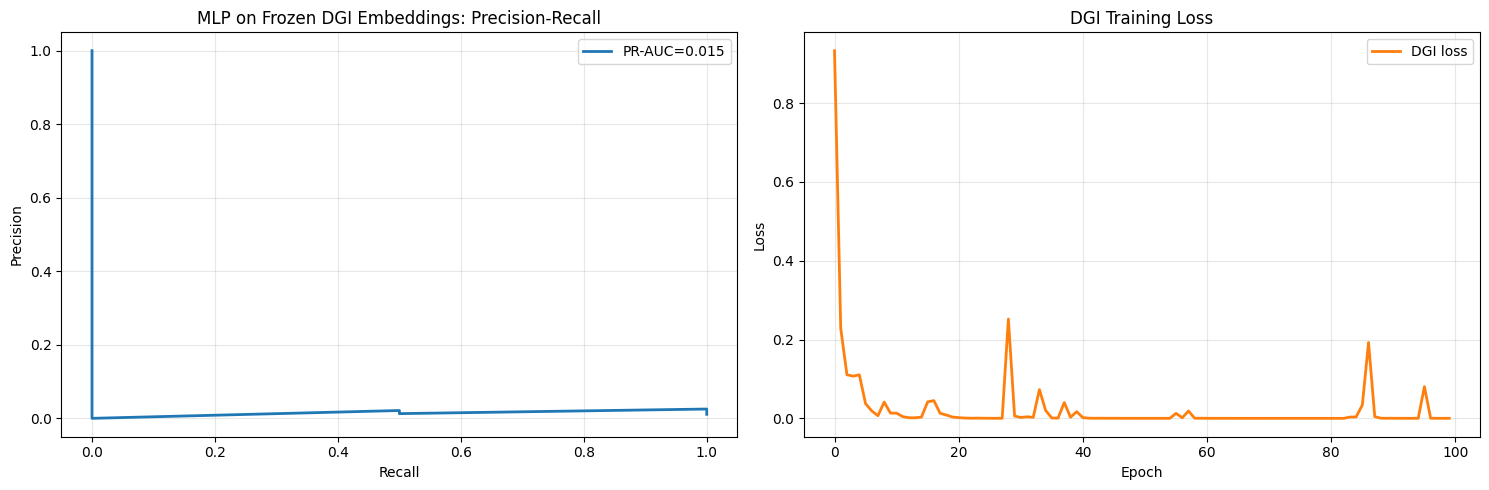


Top predicted fraud customers on the test split:
    customer_id  component  gmm_max_prob  customer_ae_risk  mlp_fraud_prob  true_label  dgi_anomaly_score
SYNID0200027516         23      0.998849          0.000071        0.484436           0       0.000000e+00
SYNID0200184466        164      1.000000          0.000142        0.483500           0       3.576279e-07
SYNID0106523980        185      1.000000          0.000067        0.482069           0       1.192093e-07
SYNID0109996010        176      1.000000          0.000058        0.480822           0       1.788139e-05
SYNID0200143186         20      1.000000          0.000059        0.480726           0       4.959106e-05
SYNID0200302254        138      1.000000          0.000131        0.480697           0       0.000000e+00
SYNID0200991884         95      1.000000          0.000072        0.479993           0       0.000000e+00
SYNID0108850119        109      1.000000          0.000102        0.479291           0       0.000000e

In [22]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, auc
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def topk_lift(y_true, y_prob, k_frac=0.05):
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob).astype(float)
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    top_idx = np.argsort(-y_prob)[:k]
    base_rate = y_true.mean() if n > 0 else 0.0
    precision_at_k = y_true[top_idx].mean() if k > 0 else 0.0
    lift = (precision_at_k / base_rate) if base_rate > 0 else 0.0
    return int(k), float(precision_at_k), float(base_rate), float(lift)


decision_threshold = float(globals().get('best_decision_threshold', 0.5))
test_eval_mask_np = test_mask.cpu().numpy() & (true_labels_np != -1)
all_labels = true_labels_np[test_eval_mask_np].astype(int)
all_probs_test = all_embedding_probs[test_eval_mask_np]
all_preds = (all_probs_test > decision_threshold).astype(int)

print(f"Test: {len(all_labels):,} ({int(all_labels.sum())} fraud, {int((all_labels == 0).sum())} legit)")
print(f"Decision threshold used: {decision_threshold:.3f}\n")
print(classification_report(all_labels, all_preds, labels=[0, 1], target_names=['Legit', 'Fraud'], digits=4, zero_division=0))

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
print(f"Confusion Matrix:\n  TN={cm[0,0]}  FP={cm[0,1]}\n  FN={cm[1,0]}  TP={cm[1,1]}")

if int((all_labels == 1).sum()) > 0:
    prec_v, rec_v, _ = precision_recall_curve(all_labels, all_probs_test)
    pr_auc = auc(rec_v, prec_v)
else:
    prec_v = np.array([0.0, 0.0])
    rec_v = np.array([1.0, 0.0])
    pr_auc = 0.0

fraud_recall = cm[1,1] / max(cm[1,1] + cm[1,0], 1)
fraud_precision = cm[1,1] / max(cm[1,1] + cm[0,1], 1)
fraud_f1 = 2 * fraud_recall * fraud_precision / max(fraud_recall + fraud_precision, 1e-8)

print(f"\nPR-AUC={pr_auc:.4f}")
print(f"Fraud Recall={fraud_recall:.4f}  Fraud Precision={fraud_precision:.4f}  F1={fraud_f1:.4f}")

print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'TP'}")
print('-' * 55)
for thr in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pt = (all_probs_test > thr).astype(int)
    tp = ((pt == 1) & (all_labels == 1)).sum()
    fp_ = ((pt == 1) & (all_labels == 0)).sum()
    fn_ = ((pt == 0) & (all_labels == 1)).sum()
    pr_ = tp / (tp + fp_) if (tp + fp_) > 0 else 0
    rc_ = tp / (tp + fn_) if (tp + fn_) > 0 else 0
    f1_ = 2 * pr_ * rc_ / (pr_ + rc_) if (pr_ + rc_) > 0 else 0
    mark = ' <== selected' if abs(thr - decision_threshold) < 1e-6 else ''
    print(f"{thr:<12.2f} {pr_:<12.4f} {rc_:<12.4f} {f1_:<10.4f} {tp}{mark}")

print("\nTop-K Lift (vs base fraud rate):")
print(f"{'K%':<8} {'Top-K N':<10} {'Precision@K':<14} {'Base Rate':<12} {'Lift':<10}")
print('-' * 60)
for kf in [0.01, 0.02, 0.05, 0.10]:
    k_n, p_at_k, base_rate, lift = topk_lift(all_labels, all_probs_test, k_frac=kf)
    print(f"{int(kf * 100):<8} {k_n:<10} {p_at_k:<14.4f} {base_rate:<12.4f} {lift:<10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(rec_v, prec_v, lw=2, label=f'PR-AUC={pr_auc:.3f}')
axes[0].set(title='MLP on Frozen DGI Embeddings: Precision-Recall', xlabel='Recall', ylabel='Precision')
axes[0].legend()
axes[0].grid(alpha=0.3)

history_df = pd.DataFrame(dgi_history)
axes[1].plot(history_df['epoch'], history_df['loss'], lw=2, color='tab:orange', label='DGI loss')
axes[1].set(title='DGI Training Loss', xlabel='Epoch', ylabel='Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_sage.png', dpi=150, bbox_inches='tight')
print("\n✓ Plots saved to model_evaluation_sage.png")
plt.show()

print('\nTop predicted fraud customers on the test split:')
test_rank_df = component_df.loc[test_eval_mask_np, ['customer_id', 'component', 'gmm_max_prob', 'customer_ae_risk']].copy()
test_rank_df['mlp_fraud_prob'] = all_probs_test
test_rank_df['true_label'] = all_labels
test_rank_df['dgi_anomaly_score'] = dgi_anomaly_score.numpy()[test_eval_mask_np]
print(test_rank_df.sort_values('mlp_fraud_prob', ascending=False).head(15).to_string(index=False))

In [15]:
# --- Diagnostic: Feature Importance for Top False Positives ---
import numpy as np
import pandas as pd

def print_top_fp_feature_importance(model, X, y_pred, y_true, feature_names, top_n=20):
    """
    Print feature values for top N false positives to diagnose static vs behavioral dominance.
    """
    fp_mask = (y_pred == 1) & (y_true == 0)
    fp_indices = np.where(fp_mask)[0]
    if len(fp_indices) == 0:
        print("No false positives found.")
        return
    # Sort by model output probability if available
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[:, 1]
        top_fp = fp_indices[np.argsort(-proba[fp_indices])][:top_n]
    else:
        top_fp = fp_indices[:top_n]
    print(f"Top {len(top_fp)} False Positives (by model score):")
    for idx in top_fp:
        print(f"\nIndex: {idx}")
        for i, fname in enumerate(feature_names):
            print(f"  {fname}: {X[idx, i]}")


# Cluster Visualization and Silhouette Score
Visualize the identified clusters in embedding space and compute the silhouette score to assess cluster quality.

# Supervised Stage Retrain — Expanded Gold Labels

Retrains Stages 6–9 using the expanded gold label set (299 confirmed fraud + 1001 legit,
augmented from 10/990 via manual review of the top-scored customers).
This cell is **self-contained** — it loads all required artifacts from disk and can be run
independently of the full GNN training pipeline.

**Stages covered:**
- Stage 6: LightGBM ranker retrain
- Stage 8: Semi-supervised Random Forest
- Stage 9: Fraud-anchor expansion (289 anchors vs. 10 previously)

**Impact:**
- LightGBM effective fraud signal: 299 × 5.0 = 1495 vs. 10 × 5.0 = 50 previously
- Anchor expansion coverage: up to 289 × 8 = 2312 pseudo-positives vs. 10 × 8 = 80
- Evaluation now meaningful: 18 fraud in val, 11 in test (vs. 2 and 1 before)


In [ ]:
# ── Stage 6-9 Supervised Pipeline Retrain (Expanded Gold Labels) ──────────────
# Retrains supervised stages using 299 confirmed fraud + 1001 legit labels.
# Loads artifacts from disk — can run without re-running GNN training.

import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import average_precision_score, roc_auc_score
import lightgbm as lgb

# ── 1. Load artifacts ─────────────────────────────────────────────────────────
print('Loading artifacts...')
rank_df = pd.read_csv('outputs/rank_df_with_anchor_expansion.csv.gz')
embeddings = np.load('outputs/dgi_customer_embeddings.npy')
new_labels = pd.read_csv('data/labels.csv.gz')
new_labels['customer_id'] = new_labels['customer_id'].astype(str)
rank_df['customer_id'] = rank_df['customer_id'].astype(str)

# ── 2. Update true_label from expanded gold labels ────────────────────────────
label_map = dict(zip(new_labels['customer_id'], new_labels['label']))
rank_df['true_label'] = rank_df['customer_id'].map(label_map).fillna(-1)
rank_df['is_labeled'] = rank_df['true_label'] != -1
rank_df['is_train_anchor'] = (rank_df['split'] == 'train') & rank_df['is_labeled']

fraud_in_train = int((rank_df['is_train_anchor'] & (rank_df['true_label'] == 1)).sum())
legit_in_train = int((rank_df['is_train_anchor'] & (rank_df['true_label'] == 0)).sum())
fraud_in_val   = int(((rank_df['split'] == 'val')  & (rank_df['true_label'] == 1)).sum())
fraud_in_test  = int(((rank_df['split'] == 'test') & (rank_df['true_label'] == 1)).sum())
print(f'Labels updated: train={fraud_in_train} fraud / {legit_in_train} legit | val={fraud_in_val} fraud | test={fraud_in_test} fraud')

# ── 3. Recompute anchor-distance features ─────────────────────────────────────
print('Recomputing anchor distance features...')
fraud_anchor_mask = rank_df['is_train_anchor'] & (rank_df['true_label'] == 1)
legit_anchor_mask = rank_df['is_train_anchor'] & (rank_df['true_label'] == 0)
fraud_anchor_idx  = rank_df.index[fraud_anchor_mask].tolist()
legit_anchor_idx  = rank_df.index[legit_anchor_mask].tolist()
fraud_anchor_embs = embeddings[rank_df.loc[fraud_anchor_idx, 'cust_idx'].values]
legit_anchor_embs = embeddings[rank_df.loc[legit_anchor_idx, 'cust_idx'].values]
all_embs = embeddings[rank_df['cust_idx'].values]

nn_fraud = NearestNeighbors(n_neighbors=min(25, len(fraud_anchor_embs)), metric='euclidean')
nn_fraud.fit(fraud_anchor_embs)
fraud_dists, _ = nn_fraud.kneighbors(all_embs)
rank_df['min_dist_to_fraud_anchor']  = fraud_dists[:, 0]
rank_df['mean_dist_to_fraud_anchor'] = fraud_dists.mean(axis=1)

nn_legit = NearestNeighbors(n_neighbors=min(5, len(legit_anchor_embs)), metric='euclidean')
nn_legit.fit(legit_anchor_embs)
legit_dists, _ = nn_legit.kneighbors(all_embs)
rank_df['min_dist_to_legit_anchor']  = legit_dists[:, 0]
rank_df['mean_dist_to_legit_anchor'] = legit_dists.mean(axis=1)

# knn_gold_fraud_count: fraud anchors within 25-nearest-neighbors
nn_25 = NearestNeighbors(n_neighbors=26, metric='euclidean')
nn_25.fit(all_embs)
_, knn_idx_25 = nn_25.kneighbors(all_embs)
knn_idx_25 = knn_idx_25[:, 1:]  # exclude self
fraud_anchor_row_set = set(fraud_anchor_idx)
rank_df['knn_gold_fraud_count'] = np.array([
    sum(1 for idx in row if idx in fraud_anchor_row_set)
    for row in knn_idx_25
])
rank_df['anchor_proximity_score'] = 1.0 / (1.0 + rank_df['min_dist_to_fraud_anchor'])
print(f'Anchor distances recomputed. Fraud anchors: {len(fraud_anchor_embs)}')

# ── 4. Stage 6: Retrain LightGBM ─────────────────────────────────────────────
print('\nStage 6: Training LightGBM ranker...')
LGB_FEATURES = [
    'emb_pca_1','emb_pca_2','emb_pca_3','emb_pca_4','emb_pca_5','emb_pca_6','emb_pca_7','emb_pca_8',
    'km_component_size','km_component_train_fraud_rate','km_component_mean_dgi',
    'hdb_component_size','hdb_component_fraud_rate_labeled','hdb_component_fraud_lift_labeled',
    'knn_mean_distance','knn_suspicious_share','knn_gold_fraud_count',
    'dist_to_fraud_centroid','dist_to_legit_centroid','centroid_margin',
    'dgi_anomaly_score','customer_ae_risk_norm','gmm_max_prob','component_confidence',
    'component_train_fraud_rate','mlp_fraud_prob','cluster_consensus_score',
    'hdb_outlier_score','min_dist_to_fraud_anchor','mean_dist_to_fraud_anchor',
    'min_dist_to_legit_anchor','anchor_proximity_score',
]
LGB_FEATURES = [c for c in LGB_FEATURES if c in rank_df.columns]

pseudo_pos_mask = ((rank_df['split'] == 'train')
                   & (rank_df['final_train_label'] == 1)
                   & ~rank_df['is_train_anchor'])
mlp_bot_thresh  = rank_df.loc[~rank_df['is_labeled'], 'mlp_fraud_prob'].quantile(0.05)
hard_neg_mask   = ((~rank_df['is_labeled'])
                   & (rank_df['mlp_fraud_prob'] <= mlp_bot_thresh)
                   & (rank_df['split'] == 'train'))
lgb_mask = rank_df['is_train_anchor'] | pseudo_pos_mask | hard_neg_mask

lgb_labels_v2 = np.where(
    rank_df['is_train_anchor'] & (rank_df['true_label'] == 1), 1,
    np.where(rank_df['is_train_anchor'] & (rank_df['true_label'] == 0), 0,
    np.where(pseudo_pos_mask, 1,
    np.where(hard_neg_mask, 0, -1))))
lgb_weights_v2 = np.where(
    rank_df['is_train_anchor'] & (rank_df['true_label'] == 1), 5.0,
    np.where(rank_df['is_train_anchor'] & (rank_df['true_label'] == 0), 1.0,
    np.where(pseudo_pos_mask, 2.5,
    np.where(hard_neg_mask, 2.0, 0.0))))

lgb_train  = rank_df[lgb_mask]
X_lgb = lgb_train[LGB_FEATURES].fillna(0.0).values
y_lgb = lgb_labels_v2[lgb_mask.values]
w_lgb = lgb_weights_v2[lgb_mask.values]
print(f'LGB train: {len(lgb_train)} rows | fraud={int((y_lgb==1).sum())} legit={int((y_lgb==0).sum())}')

val_mask = (rank_df['split'] == 'val') & rank_df['is_labeled']
X_val    = rank_df.loc[val_mask, LGB_FEATURES].fillna(0.0).values
y_val    = rank_df.loc[val_mask, 'true_label'].values.astype(int)

pos_ratio  = (y_lgb == 0).sum() / max((y_lgb == 1).sum(), 1)
lgb_model  = lgb.LGBMClassifier(
    n_estimators=800, learning_rate=0.02, num_leaves=31,
    subsample=0.85, colsample_bytree=0.85, min_child_samples=5,
    scale_pos_weight=pos_ratio, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_lgb, y_lgb, sample_weight=w_lgb,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=200)])

rank_df['lgb_fraud_prob'] = lgb_model.predict_proba(rank_df[LGB_FEATURES].fillna(0.0).values)[:, 1]
joblib.dump(lgb_model, 'outputs/lgbm_fraud_ranker.joblib')
rank_df['review_priority_score'] = (
    0.35 * rank_df['lgb_fraud_prob']
    + 0.25 * rank_df['cluster_consensus_score'].fillna(0)
    + 0.15 * rank_df['dgi_anomaly_score'].fillna(0)
    + 0.15 * rank_df['customer_ae_risk_norm'].fillna(0)
    + 0.10 * rank_df['anchor_proximity_score'].fillna(0))
rank_df['scarcity_ensemble_prob'] = (
    0.55 * rank_df['pu_bagging_prob'].fillna(rank_df['lgb_fraud_prob'])
    + 0.30 * rank_df['lgb_fraud_prob']
    + 0.15 * rank_df['review_priority_score'])
print('LGB done.')

# ── 5. Stage 8: Semi-supervised RF ────────────────────────────────────────────
print('\nStage 8: Training semi-supervised Random Forest...')
META_FEATURES = list(dict.fromkeys(
    LGB_FEATURES + ['lgb_fraud_prob','scarcity_ensemble_prob']))
META_FEATURES = [c for c in META_FEATURES if c in rank_df.columns]

top_unlab_thresh = rank_df.loc[~rank_df['is_labeled'], 'scarcity_ensemble_prob'].quantile(0.997)
bot_unlab_thresh = rank_df.loc[~rank_df['is_labeled'], 'scarcity_ensemble_prob'].quantile(0.20)

semi_labels  = np.full(len(rank_df), -1, dtype=float)
semi_weights = np.zeros(len(rank_df))
semi_labels[rank_df['is_train_anchor'] & (rank_df['true_label'] == 1)] = 1.0
semi_weights[rank_df['is_train_anchor'] & (rank_df['true_label'] == 1)] = 10.0
semi_labels[rank_df['is_train_anchor'] & (rank_df['true_label'] == 0)] = 0.0
semi_weights[rank_df['is_train_anchor'] & (rank_df['true_label'] == 0)] = 1.0

pp_unlab = (~rank_df['is_labeled']) & (rank_df['scarcity_ensemble_prob'] >= top_unlab_thresh) & (rank_df['split'] == 'train')
pn_unlab = (~rank_df['is_labeled']) & (rank_df['scarcity_ensemble_prob'] <= bot_unlab_thresh) & (rank_df['split'] == 'train')
semi_labels[pp_unlab]  = 1.0;  semi_weights[pp_unlab]  = 0.35
semi_labels[pn_unlab]  = 0.0;  semi_weights[pn_unlab]  = 0.15

semi_train = semi_labels != -1
X_semi = rank_df.loc[semi_train, META_FEATURES].fillna(0.0).values
y_semi = semi_labels[semi_train].astype(int)
w_semi = semi_weights[semi_train]
print(f'Semi-RF train: {int(semi_train.sum())} rows | fraud={int((y_semi==1).sum())} legit={int((y_semi==0).sum())}')

semi_rf = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=5,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
semi_rf.fit(X_semi, y_semi, sample_weight=w_semi)
rank_df['scarcity_semi_prob'] = semi_rf.predict_proba(rank_df[META_FEATURES].fillna(0.0).values)[:, 1]
rank_df['scarcity_semi_ensemble_prob'] = (
    0.55 * rank_df['scarcity_semi_prob']
    + 0.25 * rank_df['scarcity_ensemble_prob']
    + 0.10 * rank_df['pu_bagging_prob'].fillna(rank_df['lgb_fraud_prob'])
    + 0.10 * rank_df['cluster_consensus_score'].fillna(0))
print('Semi-RF done.')

# ── 6. Stage 9: Fraud-Anchor Expansion ────────────────────────────────────────
print('\nStage 9: Fraud-anchor expansion with', len(fraud_anchor_idx), 'anchors...')
rank_df['anchor_support_score'] = (
    0.35 * rank_df['scarcity_semi_ensemble_prob'].fillna(0)
    + 0.30 * rank_df['cluster_reliability_gate'].fillna(0)
    + 0.20 * rank_df['anchor_proximity_score'].fillna(0)
    + 0.15 * rank_df['cluster_consensus_score'].fillna(0))

suspicious_mask  = rank_df['is_suspicious_slice'].fillna(False).astype(bool)
unlab_susp_mask  = ~rank_df['is_labeled'] & suspicious_mask
unlab_susp_idx   = rank_df.index[unlab_susp_mask].values
unlab_susp_embs  = embeddings[rank_df.loc[unlab_susp_mask, 'cust_idx'].values]

dist_20th      = np.percentile(rank_df['min_dist_to_fraud_anchor'].values, 20)
support_80th   = rank_df.loc[~rank_df['is_labeled'], 'anchor_support_score'].quantile(0.80)
rel_gate_min   = 0.10
PER_ANCHOR_CAP = 8
PER_COMP_CAP   = 8

anchor_neighbor_positive = np.zeros(len(rank_df), dtype=bool)
component_cap = {}
nn_unlab = NearestNeighbors(n_neighbors=min(30, max(1, len(unlab_susp_idx))), metric='euclidean')
nn_unlab.fit(unlab_susp_embs)

for anchor_row in fraud_anchor_idx:
    anc_emb = embeddings[rank_df.loc[anchor_row, 'cust_idx']].reshape(1, -1)
    dists, nn_pos = nn_unlab.kneighbors(anc_emb, n_neighbors=min(25, len(unlab_susp_idx)))
    selected = 0
    for dist, pos in zip(dists[0], nn_pos[0]):
        if selected >= PER_ANCHOR_CAP:
            break
        cand_row = unlab_susp_idx[pos]
        comp     = int(rank_df.loc[cand_row, 'component'])
        if component_cap.get(comp, 0) >= PER_COMP_CAP:
            continue
        cand = rank_df.loc[cand_row]
        if (not anchor_neighbor_positive[cand_row]
                and dist <= dist_20th
                and float(cand['anchor_support_score']) >= support_80th
                and float(cand['cluster_reliability_gate']) >= rel_gate_min):
            anchor_neighbor_positive[cand_row] = True
            component_cap[comp] = component_cap.get(comp, 0) + 1
            selected += 1

rank_df['anchor_neighbor_positive'] = anchor_neighbor_positive
n_anchor_pos = int(anchor_neighbor_positive.sum())
print(f'Anchor pseudo-positives: {n_anchor_pos}')

anchor_labels  = np.where(
    rank_df['is_train_anchor'] & (rank_df['true_label'] == 1), 1,
    np.where(rank_df['is_train_anchor'] & (rank_df['true_label'] == 0), 0,
    np.where(anchor_neighbor_positive, 1, -1)))
anchor_weights = np.where(
    rank_df['is_train_anchor'] & (rank_df['true_label'] == 1), 5.0,
    np.where(rank_df['is_train_anchor'] & (rank_df['true_label'] == 0), 1.0,
    np.where(anchor_neighbor_positive, 0.25, 0.0)))

a_train = anchor_labels != -1
X_anc   = rank_df.loc[a_train, META_FEATURES].fillna(0.0).values
y_anc   = anchor_labels[a_train].astype(int)
w_anc   = anchor_weights[a_train]
print(f'Anchor RF train: {int(a_train.sum())} rows | fraud={int((y_anc==1).sum())} legit={int((y_anc==0).sum())}')

anchor_rf = RandomForestClassifier(n_estimators=600, max_depth=6, min_samples_leaf=5,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
anchor_rf.fit(X_anc, y_anc, sample_weight=w_anc)
rank_df['scarcity_anchor_prob'] = anchor_rf.predict_proba(rank_df[META_FEATURES].fillna(0.0).values)[:, 1]

rank_df['scarcity_anchor_ensemble_prob'] = (
    0.45 * rank_df['scarcity_anchor_prob']
    + 0.25 * rank_df['scarcity_semi_ensemble_prob']
    + 0.15 * rank_df['scarcity_ensemble_prob']
    + 0.15 * rank_df['cluster_reliability_gate'].fillna(0))

# ── 7. Update lgb_label and save ──────────────────────────────────────────────
lgb_promo  = rank_df.loc[~rank_df['is_labeled'], 'lgb_fraud_prob'].quantile(0.9997)
rank_df['lgb_label'] = np.where(
    rank_df['true_label'] == 1, 1,
    np.where((~rank_df['is_labeled']) & (rank_df['lgb_fraud_prob'] >= lgb_promo), 1,
    np.where(rank_df['true_label'] == 0, 0, -1)))

rank_df.to_csv('outputs/rank_df_with_anchor_expansion.csv.gz', index=False, compression='gzip')
joblib.dump(semi_rf,   'outputs/rf_proxy.joblib')
joblib.dump(anchor_rf, 'outputs/anchor_rf.joblib')

model_out = rank_df[['customer_id','split','true_label','lgb_label',
                      'lgb_fraud_prob','mlp_fraud_prob',
                      'scarcity_anchor_ensemble_prob','scarcity_semi_ensemble_prob',
                      'scarcity_ensemble_prob','cluster_consensus_score',
                      'dgi_anomaly_score','customer_ae_risk_norm']].copy()
model_out.rename(columns={'lgb_label':'predicted_label',
                           'scarcity_anchor_ensemble_prob':'fraud_score'}, inplace=True)
model_out.to_csv('outputs/model_output.csv', index=False)
print('\n✓ Saved rank_df_with_anchor_expansion.csv.gz and model_output.csv')

# ── 8. Evaluation ─────────────────────────────────────────────────────────────
print('\n=== Evaluation with expanded labels ===')
for sp in ['val', 'test']:
    m = (rank_df['split'] == sp) & (rank_df['true_label'] != -1)
    y = rank_df.loc[m, 'true_label'].values
    s = rank_df.loc[m, 'scarcity_anchor_ensemble_prob'].values
    n_fraud = int((y == 1).sum())
    n_legit = int((y == 0).sum())
    if n_fraud >= 2:
        ap  = average_precision_score(y, s)
        auc = roc_auc_score(y, s)
        print(f'  {sp}: {n_fraud} fraud / {n_legit} legit | AP={ap:.4f} | AUC-ROC={auc:.4f}')
    else:
        print(f'  {sp}: {n_fraud} fraud (too few for metrics)')
